
# Homework 6 — Problem 1  
## Structural Reliability Analysis Using FORM, HLRF, and Simulation Methods

This notebook presents the solution to **Problem 1** of Homework 6. The goal is to estimate the probability of failure for the nonlinear limit-state function

$$
g(X_1, X_2) = X_1^2 - 2X_2,
$$

where failure is defined as

$$
g(X_1, X_2) < 0.
$$

Two probabilistic models are considered:

### Model A: Correlated Gaussian Random Variables

In this model, the random vector

$$
(X_1, X_2)
$$

is assumed to follow a correlated bivariate Gaussian distribution.

### Model B: Non-Gaussian Random Variables with Gaussian Copula

In this model, the marginal distributions are defined as follows:

$$
X_1 \sim \text{Lognormal},
$$

$$
X_2 \sim \text{Gumbel}.
$$

The statistical dependence between $X_1$ and $X_2$ is modeled using a **Gaussian copula**.

---

For both models, the following reliability methods are applied:

1. Transformation of the random variables into the standard normal space.
2. Estimation of the design point using the **HLRF algorithm**.
3. Approximation of the failure probability using **FORM**.
4. Estimation of the failure probability using **crude Monte Carlo simulation**.
5. Importance sampling centered at the FORM design point.
6. Optimized-normal importance sampling.
7. Adaptive importance sampling.

The purpose of this analysis is to compare the accuracy and efficiency of FORM-based and simulation-based reliability methods for both Gaussian and non-Gaussian probabilistic models.



<h1>Import Libraries</h1>

In [19]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.stats import norm, lognorm, gumbel_r
from scipy.special import ndtri
from tabulate import tabulate

from scipy.optimize import minimize

warnings.filterwarnings("ignore")

<h1>Problem definition and input parameters</h1>

The limit-state function is

$$
g(X_1,X_2)=X_1^2-2X_2.
$$

The safe and failure domains are therefore

$$
g(X_1,X_2)>0 \quad \text{safe},
$$

and

$$
g(X_1,X_2)<0 \quad \text{failure}.
$$

Equivalently, failure occurs when

$$
X_2>\frac{X_1^2}{2}.
$$

The given statistical parameters are

$$
\mu_{X_1}=13,\qquad \mu_{X_2}=18,
$$

$$
\sigma_{X_1}=2,\qquad \sigma_{X_2}=5,
$$

with correlation coefficient

$$
\rho=0.5.
$$

The same first two moments and correlation are used for both probabilistic models, but the marginal distributions and dependence transformation are different.

In [5]:
# ── Matplotlib global style ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family"      : "serif",
    "font.size"        : 11,
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 12,
    "figure.dpi"       : 150,
})


#PROBLEM PARAMETERS
mu1, mu2       = 13.0, 18.0
sig1, sig2     = 2.0,  5.0
rho            = 0.5
MAX_ITER       = 50
TOL            = 1e-8

print("=" * 70)
print("HLRF ALGORITHM: MULTIVARIATE GAUSSIAN")
print("=" * 70)
print(f"\n  g(X1, X2) = X1² - 2·X2")
print(f"  μ_X1={mu1}, μ_X2={mu2}, σ_X1={sig1}, σ_X2={sig2}, ρ={rho}\n")

HLRF ALGORITHM: MULTIVARIATE GAUSSIAN

  g(X1, X2) = X1² - 2·X2
  μ_X1=13.0, μ_X2=18.0, σ_X1=2.0, σ_X2=5.0, ρ=0.5



<h1>Model A: Bivariate Gaussian model</h1>

In Model A, the random vector

$$
\mathbf{X}=
\begin{bmatrix}
X_1\\
X_2
\end{bmatrix}
$$

is assumed to follow a bivariate normal distribution:

$$
\mathbf{X}\sim \mathcal{N}(\boldsymbol{\mu},\boldsymbol{\Sigma}).
$$

The mean vector is

$$
\boldsymbol{\mu}=
\begin{bmatrix}
13\\
18
\end{bmatrix},
$$

and the covariance matrix is

$$
\boldsymbol{\Sigma}
=
\begin{bmatrix}
\sigma_{X_1}^2 & \rho\sigma_{X_1}\sigma_{X_2}\\
\rho\sigma_{X_1}\sigma_{X_2} & \sigma_{X_2}^2
\end{bmatrix}.
$$

To transform from independent standard normal space to physical space, the Cholesky factor of the covariance matrix is used:

$$
\mathbf{X}=\boldsymbol{\mu}+\mathbf{L}\mathbf{U},
$$

where

$$
\mathbf{U}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

This transformation allows the reliability problem to be solved in standard normal space.

In [6]:
R = np.array([[1.0,  rho],
              [rho,  1.0]])
L = np.linalg.cholesky(R)          # lower-triangular Cholesky of R
L_inv = np.linalg.inv(L)
D = np.diag([sig1, sig2])           # diagonal std-dev matrix
D_inv = np.diag([1/sig1, 1/sig2])

# Jacobian  dX/dU  (= D @ L)  and  dU/dX  (= L_inv @ D_inv)
J_XU = D @ L          # shape (2,2)
J_UX = L_inv @ D_inv  # shape (2,2)

def X_to_U(X):
    """Transform physical space → standard normal space."""
    return J_UX @ (X - np.array([mu1, mu2]))

def U_to_X(U):
    """Transform standard normal space → physical space."""
    return np.array([mu1, mu2]) + J_XU @ U

<h1>Model A: HLRF algorithm theory</h1>


The Hasofer–Lind–Rackwitz–Fiessler algorithm searches for the **design point**  $(\mathbf{u}^*)$, which is the closest point on the failure surface to the origin in standard normal space.

The transformed limit-state function is

$$
G(\mathbf{u})=g\left(\mathbf{X}(\mathbf{u})\right).
$$

The HLRF update equation is

$$
\mathbf{u}^{(k+1)}
=
\frac{
\nabla G(\mathbf{u}^{(k)})^T\mathbf{u}^{(k)}
-
G(\mathbf{u}^{(k)})
}
{
\left\|\nabla G(\mathbf{u}^{(k)})\right\|^2
}
\nabla G(\mathbf{u}^{(k)}).
$$

The reliability index is the distance from the origin to the design point:

$$
\beta=\|\mathbf{u}^*\|.
$$

The FORM estimate of the probability of failure is

$$
P_f^{\text{FORM}}=\Phi(-\beta),
$$

where $(\Phi(\cdot))$ is the standard normal cumulative distribution function.

In [7]:
# LIMIT STATE FUNCTION AND GRADIENT (physical space)
def g_X(X):
    """Limit state function in physical space."""
    return X[0]**2 - 2*X[1]

def grad_g_X(X):
    """Gradient of g w.r.t. X."""
    return np.array([2*X[0], -2.0])

def G_U(U):
    """Limit state function in U-space."""
    return g_X(U_to_X(U))

def grad_G_U(U):
    """
    Gradient of G in U-space via chain rule:
       ∇G_U = J_XU^T  @ ∇g_X
    """
    X = U_to_X(U)
    return J_XU.T @ grad_g_X(X)

# 4.  HLRF ITERATION
print("  Cholesky factor L (lower):")
print(f"    L = [[{L[0,0]:.4f}, {L[0,1]:.4f}],")
print(f"         [{L[1,0]:.4f}, {L[1,1]:.4f}]]\n")

U      = np.zeros(2)          # start at origin (= mean point)
rows   = []                   # iteration table
U_hist = [U.copy()]
X_hist = [U_to_X(U)]

for k in range(1, MAX_ITER+1):
    X       = U_to_X(U)
    Gval    = G_U(U)
    dGdU    = grad_G_U(U)
    norm_dG = np.linalg.norm(dGdU)
    beta_k  = np.dot(dGdU, U) / norm_dG   # projection

    rows.append([k,
                 round(U[0], 6), round(U[1], 6),
                 round(X[0], 6), round(X[1], 6),
                 round(Gval, 6),
                 round(norm_dG, 6),
                 round(np.linalg.norm(U), 6)])

    # HLRF update
    U_new = ((np.dot(dGdU, U) - Gval) / norm_dG**2) * dGdU

    # convergence check
    if np.linalg.norm(U_new - U) < TOL and abs(G_U(U_new)) < TOL:
        U = U_new
        break

    U = U_new
    U_hist.append(U.copy())
    X_hist.append(U_to_X(U))

U_star    = U
X_star    = U_to_X(U_star)
beta_FORM = np.linalg.norm(U_star)
Pf_FORM   = norm.cdf(-beta_FORM)

  Cholesky factor L (lower):
    L = [[1.0000, 0.0000],
         [0.5000, 0.8660]]



<h1>Model A: HLRF results and interpretation</h1>



After convergence, the HLRF algorithm gives the design point in standard normal space:

$$
\mathbf{u}^*=(u_1^*,u_2^*).
$$

The corresponding physical design point is obtained from

$$
\mathbf{x}^*=\boldsymbol{\mu}+\mathbf{L}\mathbf{u}^*.
$$

At convergence, the design point must satisfy the failure boundary condition

$$
g(\mathbf{x}^*)\approx 0.
$$

For the Gaussian model, the design point is expected to lie in the lower tail of $(X_1)$ and the upper region of $(X_2)$, because failure occurs when

$$
X_2>\frac{X_1^2}{2}.
$$

Physically, this means failure is driven mainly by a reduction in the resistance term $(X_1^2)$, together with a sufficiently large value of $(X_2)$.

In [8]:
# PRINT ITERATION TABLE
headers = ["Iter", "u1", "u2", "x1", "x2", "G(U)", "‖∇G‖", "‖u‖(=β)"]
print("\n  ── HLRF Iteration Table (Gaussian Case) ─────────────────────────\n")
print(tabulate(rows, headers=headers, tablefmt="fancy_grid",
               floatfmt=(".0f",".6f",".6f",".6f",".6f",".6f",".6f",".6f")))

print(f"\n  ══ FORM Results (Gaussian) ═════════════════════════════════════")
print(f"     Design point U* = ({U_star[0]:.6f}, {U_star[1]:.6f})")
print(f"     Design point X* = ({X_star[0]:.6f}, {X_star[1]:.6f})")
print(f"     Reliability index  β = {beta_FORM:.6f}")
print(f"     P_f (FORM)           = {Pf_FORM:.6e}")
print(f"     g(X*) = {g_X(X_star):.2e}  (should ≈ 0)\n")


  ── HLRF Iteration Table (Gaussian Case) ─────────────────────────

╒════════╤═══════════╤══════════╤═══════════╤═══════════╤════════════╤═══════════╤═══════════╕
│   Iter │        u1 │       u2 │        x1 │        x2 │       G(U) │      ‖∇G‖ │   ‖u‖(=β) │
╞════════╪═══════════╪══════════╪═══════════╪═══════════╪════════════╪═══════════╪═══════════╡
│      1 │  0.000000 │ 0.000000 │ 13.000000 │ 18.000000 │ 133.000000 │ 47.791213 │  0.000000 │
├────────┼───────────┼──────────┼───────────┼───────────┼────────────┼───────────┼───────────┤
│      2 │ -2.736865 │ 0.504297 │  7.526270 │ 13.341506 │  29.961723 │ 26.556826 │  2.782938 │
├────────┼───────────┼──────────┼───────────┼───────────┼────────────┼───────────┼───────────┤
│      3 │ -3.667819 │ 1.265252 │  5.664363 │ 14.309154 │   3.466698 │ 19.666865 │  3.879917 │
├────────┼───────────┼──────────┼───────────┼───────────┼────────────┼───────────┼───────────┤
│      4 │ -3.615093 │ 1.773054 │  5.769814 │ 16.639819 │   0.011120 │ 20.0

<h1>Model A: Plotting the design point search sequence</h1>

The HLRF search sequence is plotted in two spaces:

1. **Original physical space** $((X_1,X_2))$, where the failure boundary is

$$
X_2=\frac{X_1^2}{2}.
$$

2. **Standard normal space** $((U_1,U_2))$, where the design point is the point on the transformed failure boundary closest to the origin.

In standard normal space, circles centered at the origin represent constant reliability index:

$$
\|\mathbf{u}\|=\beta.
$$

The final design point $(\mathbf{u}^*)$ lies on the circle with radius equal to the FORM reliability index.

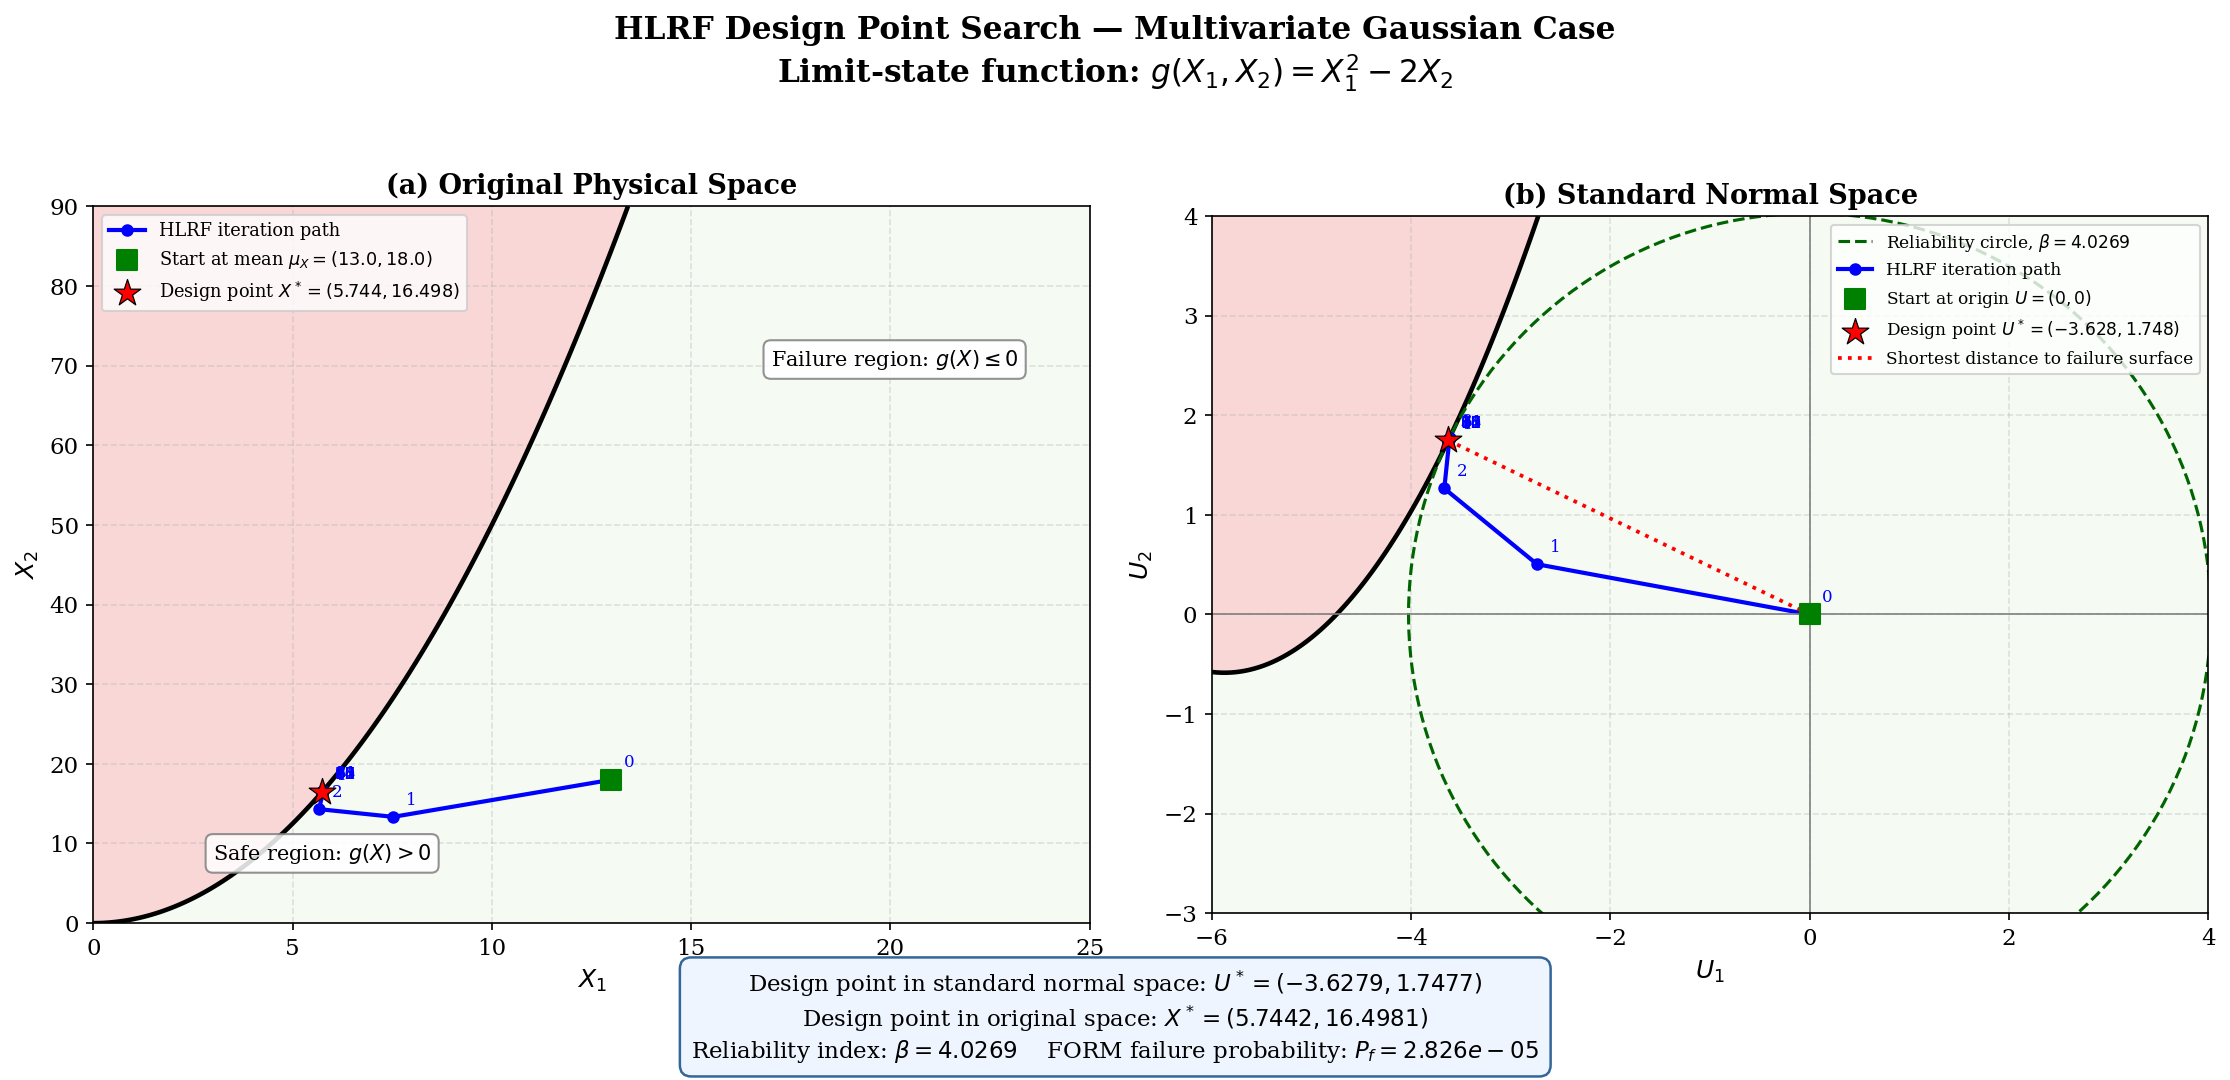

Plot saved as:
  problem1_gaussian_hlrf_design_point.png
  problem1_gaussian_hlrf_design_point.pdf


In [9]:
# HLRF DESIGN POINT SEARCH SEQUENCE
#Case A: Multivariate Gaussian Distribution

U_hist = np.array(U_hist)
X_hist = np.array(X_hist)


if np.linalg.norm(U_hist[-1] - U_star) > 1e-10:
    U_hist = np.vstack([U_hist, U_star])
    X_hist = np.vstack([X_hist, X_star])

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

fig.suptitle(
    "HLRF Design Point Search — Multivariate Gaussian Case\n"
    r"Limit-state function: $g(X_1,X_2)=X_1^2-2X_2$",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

# (a) Original Physical Space
ax = axes[0]

x1_vals = np.linspace(0, 25, 500)
x2_vals = np.linspace(0, 90, 500)
X1_grid, X2_grid = np.meshgrid(x1_vals, x2_vals)
G_grid_X = X1_grid**2 - 2 * X2_grid

# Failure and safe regions
ax.contourf(
    X1_grid, X2_grid, G_grid_X,
    levels=[-1e10, 0],
    colors=["#f6b6b6"],
    alpha=0.55
)

ax.contourf(
    X1_grid, X2_grid, G_grid_X,
    levels=[0, 1e10],
    colors=["#d8f0d2"],
    alpha=0.25
)

# Limit-state boundary g = 0
ax.contour(
    X1_grid, X2_grid, G_grid_X,
    levels=[0],
    colors="black",
    linewidths=2.2
)

# HLRF path
ax.plot(
    X_hist[:, 0], X_hist[:, 1],
    "o-",
    color="blue",
    linewidth=2,
    markersize=5,
    label="HLRF iteration path"
)

# Annotate iteration numbers
for i, (x1_i, x2_i) in enumerate(X_hist):
    ax.annotate(
        f"{i}",
        (x1_i, x2_i),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color="blue"
    )

# Start and design point
ax.scatter(
    X_hist[0, 0], X_hist[0, 1],
    s=90,
    color="green",
    marker="s",
    zorder=5,
    label=rf"Start at mean $\mu_X=({mu1:.1f},{mu2:.1f})$"
)

ax.scatter(
    X_star[0], X_star[1],
    s=180,
    color="red",
    marker="*",
    edgecolor="black",
    linewidth=0.6,
    zorder=6,
    label=rf"Design point $X^*=({X_star[0]:.3f},{X_star[1]:.3f})$"
)

# Text label for failure region
ax.text(
    17, 70,
    r"Failure region: $g(X)\leq 0$",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.85)
)

ax.text(
    3, 8,
    r"Safe region: $g(X)>0$",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.85)
)

ax.set_title("(a) Original Physical Space", fontsize=13, fontweight="bold")
ax.set_xlabel(r"$X_1$", fontsize=12)
ax.set_ylabel(r"$X_2$", fontsize=12)
ax.set_xlim(0, 25)
ax.set_ylim(0, 90)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper left", fontsize=8.5, frameon=True)

# (b) Standard Normal Space
ax = axes[1]

u1_vals = np.linspace(-6, 4, 500)
u2_vals = np.linspace(-3, 4, 500)
U1_grid, U2_grid = np.meshgrid(u1_vals, u2_vals)

# Vectorized transformation from U-space to X-space
X1_from_U = mu1 + sig1 * U1_grid
X2_from_U = mu2 + sig2 * (rho * U1_grid + np.sqrt(1 - rho**2) * U2_grid)

G_grid_U = X1_from_U**2 - 2 * X2_from_U

# Failure and safe regions
ax.contourf(
    U1_grid, U2_grid, G_grid_U,
    levels=[-1e10, 0],
    colors=["#f6b6b6"],
    alpha=0.55
)

ax.contourf(
    U1_grid, U2_grid, G_grid_U,
    levels=[0, 1e10],
    colors=["#d8f0d2"],
    alpha=0.25
)

# Limit-state boundary G(U) = 0
ax.contour(
    U1_grid, U2_grid, G_grid_U,
    levels=[0],
    colors="black",
    linewidths=2.2
)

# Reliability circle
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(
    beta_FORM * np.cos(theta),
    beta_FORM * np.sin(theta),
    linestyle="--",
    color="darkgreen",
    linewidth=1.5,
    label=rf"Reliability circle, $\beta={beta_FORM:.4f}$"
)

# HLRF path
ax.plot(
    U_hist[:, 0], U_hist[:, 1],
    "o-",
    color="blue",
    linewidth=2,
    markersize=5,
    label="HLRF iteration path"
)

# Annotate iteration numbers
for i, (u1_i, u2_i) in enumerate(U_hist):
    ax.annotate(
        f"{i}",
        (u1_i, u2_i),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color="blue"
    )

# Origin and design point
ax.scatter(
    U_hist[0, 0], U_hist[0, 1],
    s=90,
    color="green",
    marker="s",
    zorder=5,
    label=r"Start at origin $U=(0,0)$"
)

ax.scatter(
    U_star[0], U_star[1],
    s=180,
    color="red",
    marker="*",
    edgecolor="black",
    linewidth=0.6,
    zorder=6,
    label=rf"Design point $U^*=({U_star[0]:.3f},{U_star[1]:.3f})$"
)

# Shortest distance line from origin to design point
ax.plot(
    [0, U_star[0]],
    [0, U_star[1]],
    color="red",
    linestyle=":",
    linewidth=1.8,
    label=r"Shortest distance to failure surface"
)

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)

ax.set_title("(b) Standard Normal Space", fontsize=13, fontweight="bold")
ax.set_xlabel(r"$U_1$", fontsize=12)
ax.set_ylabel(r"$U_2$", fontsize=12)
ax.set_xlim(-6, 4)
ax.set_ylim(-3, 4)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper right", fontsize=8.2, frameon=True)

# ════════════════════════════════════════════════════════════════════════════
# Result summary box
# ════════════════════════════════════════════════════════════════════════════
summary_text = (
    rf"Design point in standard normal space: $U^*=({U_star[0]:.4f}, {U_star[1]:.4f})$" "\n"
    rf"Design point in original space: $X^*=({X_star[0]:.4f}, {X_star[1]:.4f})$" "\n"
    rf"Reliability index: $\beta={beta_FORM:.4f}$    "
    rf"FORM failure probability: $P_f={Pf_FORM:.3e}$"
)

fig.text(
    0.5, -0.04,
    summary_text,
    ha="center",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#eef5ff",
        edgecolor="#336699",
        linewidth=1.2
    )
)

plt.tight_layout()

# Save in the same directory as your Jupyter notebook
plt.savefig(
    "problem1_gaussian_hlrf_design_point.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "problem1_gaussian_hlrf_design_point.pdf",
    bbox_inches="tight"
)

plt.show()

print("Plot saved as:")
print("  problem1_gaussian_hlrf_design_point.png")
print("  problem1_gaussian_hlrf_design_point.pdf")

<h1>Model B: Lognormal–Gumbel model with Gaussian copula</h1>

In Model B, the marginal distributions are changed while keeping the same mean, standard deviation, and correlation coefficient:

- $(X_1)$ follows a **lognormal distribution**,
- $(X_2)$ follows a **Gumbel Type-I distribution**,
- dependence is introduced through a **Gaussian copula**.

For the lognormal variable $(X_1)$, the log-space parameters are obtained from the original mean and standard deviation:

$$
\sigma_{\ln X_1}
=
\sqrt{
\ln\left(1+\frac{\sigma_{X_1}^2}{\mu_{X_1}^2}\right)
},
$$

$$
\mu_{\ln X_1}
=
\ln(\mu_{X_1})
-
\frac{1}{2}\sigma_{\ln X_1}^2.
$$

For the Gumbel variable $(X_2)$, the distribution parameters are obtained from its mean and standard deviation.  
The Gaussian copula correlation is corrected using

$$
\rho_0=C\rho,
$$

where

$$
C=1.023.
$$

Therefore,

$$
\rho_0=1.023(0.5)=0.5115.
$$

This model is non-Gaussian because the marginal transformations are nonlinear.

In [12]:
plt.rcParams.update({
    "font.family"  : "serif",
    "font.size"    : 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.dpi"   : 150,
})

# 1.  PARAMETERS
mu1_X,  sig1_X  = 13.0, 2.0     # X1 LogNormal moments
mu2_X,  sig2_X  = 18.0, 5.0     # X2 Gumbel   moments
rho              = 0.5
C                = 1.023          # copula correction factor (given)
rho0             = C * rho        # ρ₀ used in Gaussian copula
MAX_ITER         = 80
TOL              = 1e-8

print("=" * 70)
print("HLRF: LOGNORMAL + GUMBEL + GAUSSIAN COPULA")
print("=" * 70)
print(f"\n  X1 ~ LogNormal: μ={mu1_X}, σ={sig1_X}")
print(f"  X2 ~ Gumbel   : μ={mu2_X}, σ={sig2_X}")
print(f"  ρ = {rho},  C = {C},  ρ₀ = {rho0:.4f}\n")

HLRF: LOGNORMAL + GUMBEL + GAUSSIAN COPULA

  X1 ~ LogNormal: μ=13.0, σ=2.0
  X2 ~ Gumbel   : μ=18.0, σ=5.0
  ρ = 0.5,  C = 1.023,  ρ₀ = 0.5115



<h1>Model B: Nataf / Gaussian copula transformation</h1>

For the non-Gaussian model, the transformation is performed using the marginal CDFs and the Gaussian copula.

Each physical variable is first mapped to an equivalent correlated standard normal variable:

$$
\tilde{u}_i=\Phi^{-1}\left(F_{X_i}(x_i)\right),
$$

where $(F_{X_i})$ is the marginal CDF of $(X_i)$.

The correlated standard normal vector $(\tilde{\mathbf{u}})$ is then related to the independent standard normal vector $(\mathbf{u})$ using the Cholesky factor of the copula correlation matrix:

$$
\tilde{\mathbf{u}}=\mathbf{L}_0\mathbf{u}.
$$

Therefore, the complete transformation is

$$
\mathbf{x}
\longrightarrow
\tilde{\mathbf{u}}
\longrightarrow
\mathbf{u}.
$$

The inverse transformation is used inside the HLRF algorithm to evaluate the limit-state function in standard normal space:

$$
G(\mathbf{u})=g\left(T^{-1}(\mathbf{u})\right).
$$

In [13]:
# LOGNORMAL PARAMETERS (from moments)
sig_ln1 = np.sqrt(np.log(1 + (sig1_X/mu1_X)**2))
mu_ln1  = np.log(mu1_X) - 0.5*sig_ln1**2
print(f"  LogNormal params: μ_ln={mu_ln1:.6f}, σ_ln={sig_ln1:.6f}")


# GUMBEL PARAMETERS (from moments)
euler_gamma = 0.5772156649015329
beta_G2 = np.pi / (sig2_X * np.sqrt(6))          # scale param (1/scale)
u_G2    = mu2_X - euler_gamma / beta_G2           # location param
print(f"  Gumbel params  : u_G={u_G2:.6f}, β_G (rate)={beta_G2:.6f}\n")

# COPULA CORRELATION MATRIX AND CHOLESKY
R0    = np.array([[1.0,  rho0],
                  [rho0, 1.0]])
L0    = np.linalg.cholesky(R0)
L0inv = np.linalg.inv(L0)

print(f"  Copula correlation ρ₀ = {rho0:.4f}")
print(f"  L₀ (Cholesky) = [[{L0[0,0]:.4f}, {L0[0,1]:.4f}],")
print(f"                    [{L0[1,0]:.4f}, {L0[1,1]:.4f}]]\n")


# TRANSFORMATION FUNCTIONS

CLIP = 1e-10  

def F1(x):
    """CDF of X1 (LogNormal)."""
    return norm.cdf((np.log(x) - mu_ln1) / sig_ln1)

def f1(x):
    """PDF of X1 (LogNormal)."""
    return (1 / (x * sig_ln1)) * norm.pdf((np.log(x) - mu_ln1) / sig_ln1)

def F2(x):
    """CDF of X2 (Gumbel max): F(x) = exp(-exp(-β_G(x-u_G)))."""
    return np.exp(-np.exp(-beta_G2*(x - u_G2)))

def f2(x):
    """PDF of X2 (Gumbel max)."""
    z = beta_G2*(x - u_G2)
    return beta_G2 * np.exp(-z - np.exp(-z))

def X_to_U(X):
    """Physical → standard normal U via Nataf / Gaussian copula."""
    x1, x2 = X[0], X[1]
    p1 = np.clip(F1(x1), CLIP, 1-CLIP)
    p2 = np.clip(F2(x2), CLIP, 1-CLIP)
    Utilde = np.array([norm.ppf(p1), norm.ppf(p2)])
    return L0inv @ Utilde

def U_to_X(U):
    """Standard normal U → physical X via inverse Nataf."""
    Utilde = L0 @ U
    x1 = np.exp(mu_ln1 + sig_ln1 * Utilde[0])
    # Gumbel inverse CDF: x = u_G - ln(-ln(p)) / β_G
    p2 = np.clip(norm.cdf(Utilde[1]), CLIP, 1-CLIP)
    x2 = u_G2 - np.log(-np.log(p2)) / beta_G2
    return np.array([x1, x2])

  LogNormal params: μ_ln=2.553253, σ_ln=0.152947
  Gumbel params  : u_G=15.749734, β_G (rate)=0.256510

  Copula correlation ρ₀ = 0.5115
  L₀ (Cholesky) = [[1.0000, 0.0000],
                    [0.5115, 0.8593]]



<h1>Model B: HLRF algorithm</h1>

The HLRF procedure is repeated for the non-Gaussian model.  
The same update equation is used:

$$
\mathbf{u}^{(k+1)}
=
\frac{
\nabla G(\mathbf{u}^{(k)})^T\mathbf{u}^{(k)}
-
G(\mathbf{u}^{(k)})
}
{
\left\|\nabla G(\mathbf{u}^{(k)})\right\|^2
}
\nabla G(\mathbf{u}^{(k)}).
$$

However, the transformed limit-state function $G(\mathbf{u})$ is now more nonlinear because the inverse transformation involves:

- the inverse lognormal transformation for $(X_1)$,
- the inverse Gumbel transformation for $(X_2)$,
- the Gaussian copula dependence transformation.

The gradient $\nabla G(\mathbf{u})$ is therefore evaluated numerically using central finite differences.

In [17]:
#LIMIT STATE AND GRADIENT IN U-SPACE
def g_X(X):
    return X[0]**2 - 2*X[1]

def G_U(U):
    return g_X(U_to_X(U))

def grad_G_U(U, eps=1e-5):
    """
    Gradient via Nataf chain rule:
       ∇G_U = J_XU^T ∇g_X
    where  J_XU = dX/dU = D_Utilde @ L0,
           D_Utilde = diag(f_Xi(x_i) / φ(Ũ_i))^{-1}  ... see below.

    We also compute it via finite differences for verification.
    """
    X       = U_to_X(U)
    # Marginal standard-normal equivalents
    Utilde  = L0 @ U
    phi_u   = norm.pdf(Utilde)                # φ(Ũ_i)

    # Jacobian dX_i/dŨ_i  (diagonal terms)
    # dx1/dU1_tilde = 1/(f1(x1)/φ(Ũ1))  ... Nataf equivalence
    dX1_dU1t = phi_u[0] / f1(X[0])
    dX2_dU2t = phi_u[1] / f2(X[1])

    D_diag = np.array([dX1_dU1t, dX2_dU2t])   # diagonal of dX/dŨ
    # Full Jacobian dX/dU = D_mat @ L0
    J_XU = np.diag(D_diag) @ L0

    grad_g = np.array([2*X[0], -2.0])
    return J_XU.T @ grad_g



<h1>Model B: Results and interpretation</h1>

In [15]:
# HLRF ITERATIONS
# Start from mean point
X0 = np.array([mu1_X, mu2_X])
U  = X_to_U(X0)

rows   = []
U_hist = [U.copy()]
X_hist = [X0.copy()]

for k in range(1, MAX_ITER+1):
    X       = U_to_X(U)
    Gval    = g_X(X)
    dGdU    = grad_G_U(U)
    norm_dG = np.linalg.norm(dGdU)

    rows.append([k,
                 round(U[0], 6), round(U[1], 6),
                 round(X[0], 6), round(X[1], 6),
                 round(Gval, 6),
                 round(norm_dG, 6),
                 round(np.linalg.norm(U), 6)])

    U_new = ((np.dot(dGdU, U) - Gval) / norm_dG**2) * dGdU

    if np.linalg.norm(U_new - U) < TOL and abs(G_U(U_new)) < TOL:
        U = U_new
        break

    U = U_new
    U_hist.append(U.copy())
    X_hist.append(U_to_X(U).copy())

U_star    = U
X_star    = U_to_X(U_star)
beta_FORM = np.linalg.norm(U_star)
Pf_FORM   = norm.cdf(-beta_FORM)

# PRINT TABLE
headers = ["Iter", "u1", "u2", "x1", "x2", "g(X)", "‖∇G‖", "‖u‖(=β)"]
print("\n  ── HLRF Iteration Table (Lognormal+Gumbel+Copula) ───────────────\n")
print(tabulate(rows, headers=headers, tablefmt="fancy_grid",
               floatfmt=(".0f",".6f",".6f",".6f",".6f",".6f",".6f",".6f")))

print(f"\n  ══ FORM Results (Lognormal + Gumbel + Gaussian Copula) ═════════")
print(f"     Design point U* = ({U_star[0]:.6f}, {U_star[1]:.6f})")
print(f"     Design point X* = ({X_star[0]:.6f}, {X_star[1]:.6f})")
print(f"     Reliability index  β = {beta_FORM:.6f}")
print(f"     P_f (FORM)           = {Pf_FORM:.6e}")
print(f"     g(X*) = {g_X(X_star):.2e}  (should ≈ 0)\n")


  ── HLRF Iteration Table (Lognormal+Gumbel+Copula) ───────────────

╒════════╤═══════════╤══════════╤═══════════╤═══════════╤════════════╤═══════════╤═══════════╕
│   Iter │        u1 │       u2 │        x1 │        x2 │       g(X) │      ‖∇G‖ │   ‖u‖(=β) │
╞════════╪═══════════╪══════════╪═══════════╪═══════════╪════════════╪═══════════╪═══════════╡
│      1 │  0.076474 │ 0.160849 │ 13.000000 │ 18.000000 │ 133.000000 │ 47.521104 │  0.178103 │
├────────┼───────────┼──────────┼───────────┼───────────┼────────────┼───────────┼───────────┤
│      2 │ -2.709812 │ 0.475671 │  8.489197 │ 13.443866 │  45.178736 │ 19.534535 │  2.751244 │
├────────┼───────────┼──────────┼───────────┼───────────┼────────────┼───────────┼───────────┤
│      3 │ -4.834516 │ 1.443428 │  6.133875 │ 12.644937 │  12.334547 │  9.890587 │  5.045397 │
├────────┼───────────┼──────────┼───────────┼───────────┼────────────┼───────────┼───────────┤
│      4 │ -5.215052 │ 3.205780 │  5.787062 │ 17.575887 │  -1.661682 │  9.6

<h1>Model B: Plotting the design point search sequence</h1>

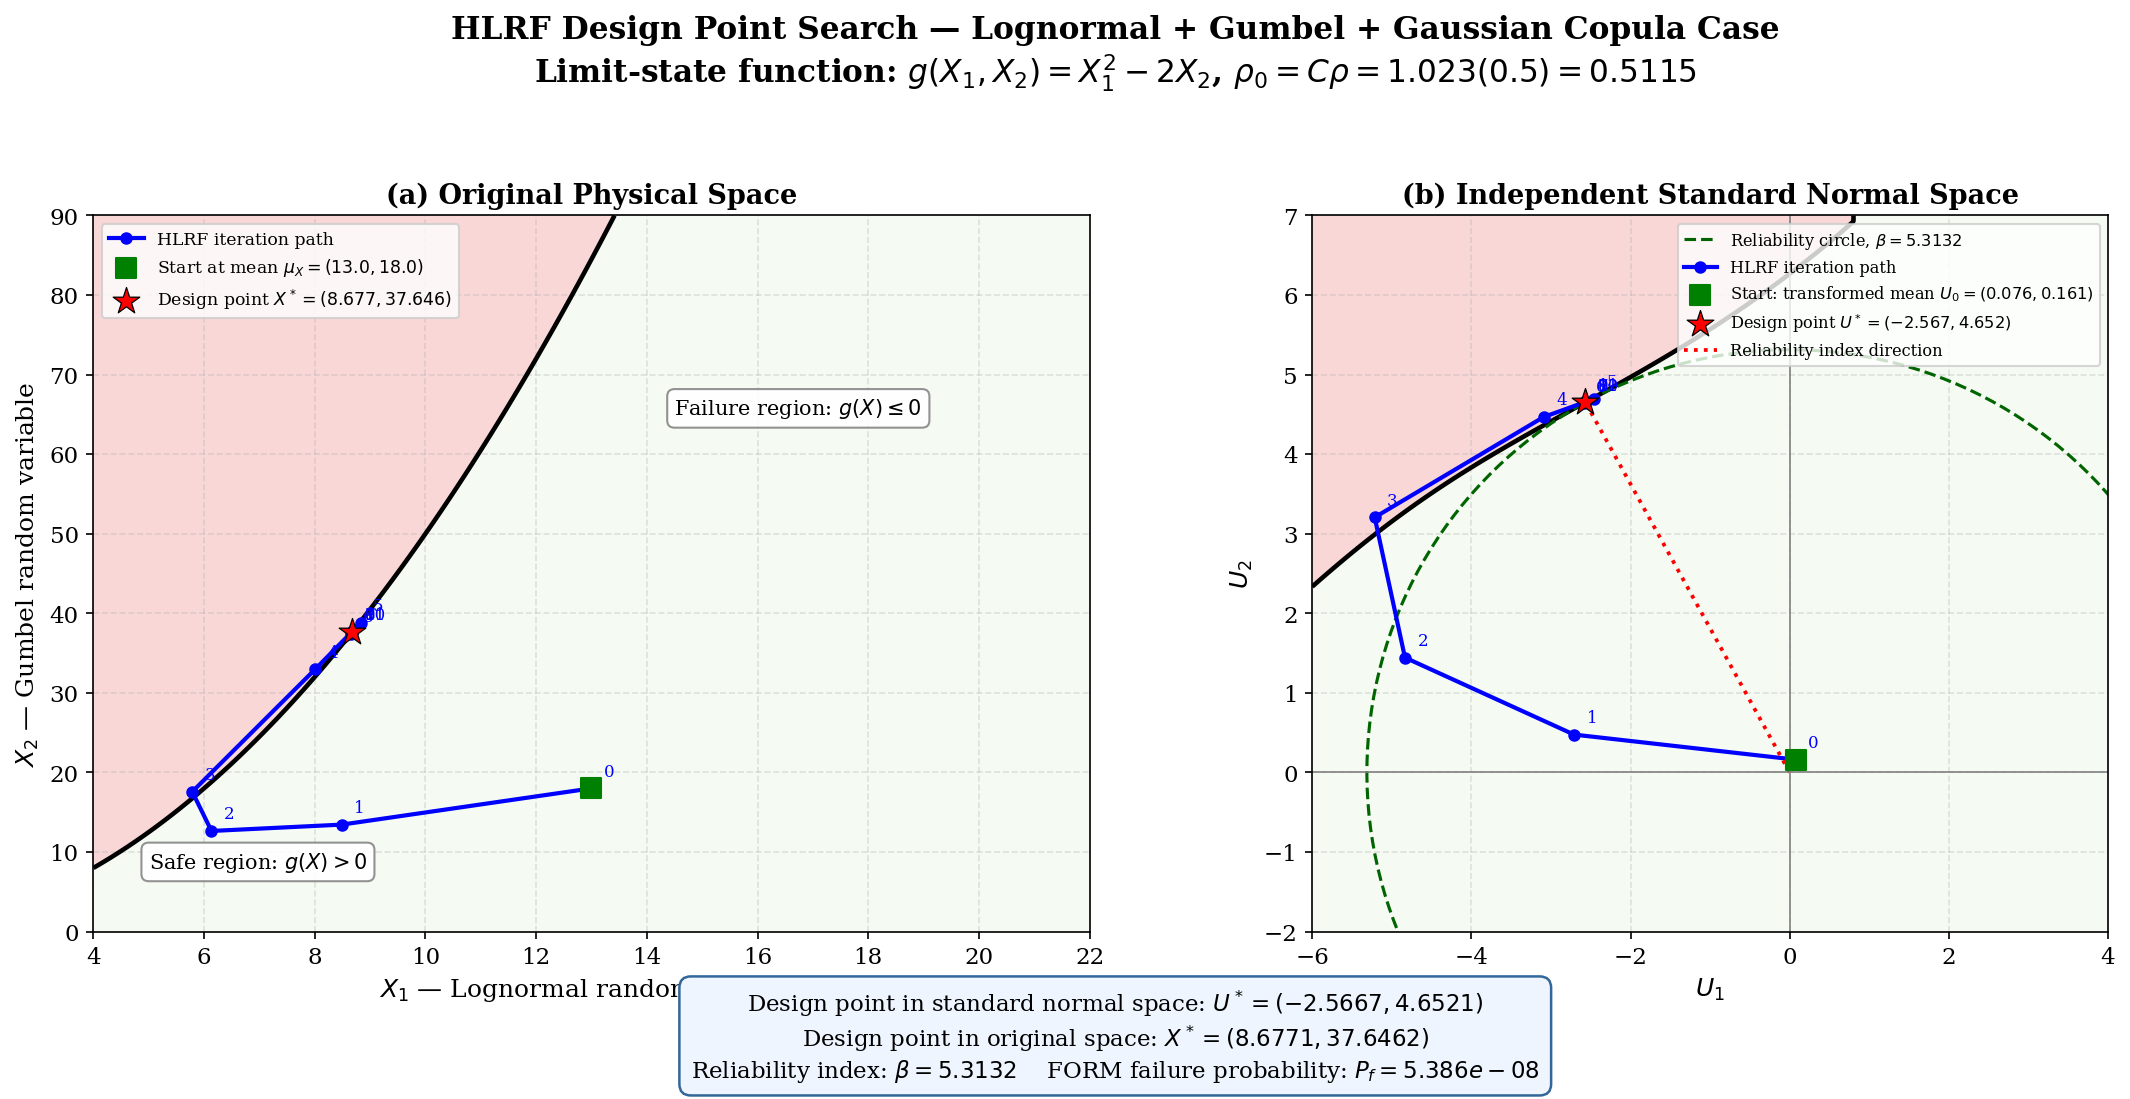

Plot saved as:
  problem1_lognormal_gumbel_copula_hlrf_design_point.png
  problem1_lognormal_gumbel_copula_hlrf_design_point.pdf


In [18]:
# HLRF DESIGN POINT SEARCH SEQUENCE
# Case B: Lognormal + Gumbel + Gaussian Copula


U_hist = np.array(U_hist)
X_hist = np.array(X_hist)


if np.linalg.norm(U_hist[-1] - U_star) > 1e-10:
    U_hist = np.vstack([U_hist, U_star])
    X_hist = np.vstack([X_hist, X_star])

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

fig.suptitle(
    "HLRF Design Point Search — Lognormal + Gumbel + Gaussian Copula Case\n"
    r"Limit-state function: $g(X_1,X_2)=X_1^2-2X_2$, "
    r"$\rho_0=C\rho=1.023(0.5)=0.5115$",
    fontsize=15,
    fontweight="bold",
    y=1.04
)


# (a) Original Physical Space

ax = axes[0]

x1_vals = np.linspace(4, 22, 500)
x2_vals = np.linspace(0, 90, 500)
X1_grid, X2_grid = np.meshgrid(x1_vals, x2_vals)
G_grid_X = X1_grid**2 - 2 * X2_grid

# Failure region: g(X) <= 0
ax.contourf(
    X1_grid, X2_grid, G_grid_X,
    levels=[-1e10, 0],
    colors=["#f6b6b6"],
    alpha=0.55
)

# Safe region: g(X) > 0
ax.contourf(
    X1_grid, X2_grid, G_grid_X,
    levels=[0, 1e10],
    colors=["#d8f0d2"],
    alpha=0.25
)

# Limit-state boundary
ax.contour(
    X1_grid, X2_grid, G_grid_X,
    levels=[0],
    colors="black",
    linewidths=2.2
)

# HLRF iteration path
ax.plot(
    X_hist[:, 0], X_hist[:, 1],
    "o-",
    color="blue",
    linewidth=2,
    markersize=5,
    label="HLRF iteration path"
)

# Iteration numbers
for i, (x1_i, x2_i) in enumerate(X_hist):
    ax.annotate(
        f"{i}",
        (x1_i, x2_i),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color="blue"
    )

# Start point
ax.scatter(
    X_hist[0, 0], X_hist[0, 1],
    s=90,
    color="green",
    marker="s",
    zorder=5,
    label=rf"Start at mean $\mu_X=({mu1_X:.1f},{mu2_X:.1f})$"
)

# Design point
ax.scatter(
    X_star[0], X_star[1],
    s=180,
    color="red",
    marker="*",
    edgecolor="black",
    linewidth=0.6,
    zorder=6,
    label=rf"Design point $X^*=({X_star[0]:.3f},{X_star[1]:.3f})$"
)

# Region labels
ax.text(
    14.5, 65,
    r"Failure region: $g(X)\leq 0$",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.85)
)

ax.text(
    5.0, 8,
    r"Safe region: $g(X)>0$",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.85)
)

ax.set_title("(a) Original Physical Space", fontsize=13, fontweight="bold")
ax.set_xlabel(r"$X_1$ — Lognormal random variable", fontsize=12)
ax.set_ylabel(r"$X_2$ — Gumbel random variable", fontsize=12)
ax.set_xlim(4, 22)
ax.set_ylim(0, 90)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper left", fontsize=8.3, frameon=True)

# (b) Standard Normal Space

ax = axes[1]

u1_vals = np.linspace(-6, 4, 500)
u2_vals = np.linspace(-2, 7, 500)
U1_grid, U2_grid = np.meshgrid(u1_vals, u2_vals)

# Vectorized transformation from U-space to physical X-space
Utilde1 = L0[0, 0] * U1_grid + L0[0, 1] * U2_grid
Utilde2 = L0[1, 0] * U1_grid + L0[1, 1] * U2_grid

# X1 inverse lognormal transformation
X1_from_U = np.exp(mu_ln1 + sig_ln1 * Utilde1)

# X2 inverse Gumbel transformation
P2_from_U = np.clip(norm.cdf(Utilde2), CLIP, 1 - CLIP)
X2_from_U = u_G2 - np.log(-np.log(P2_from_U)) / beta_G2

G_grid_U = X1_from_U**2 - 2 * X2_from_U

# Failure region
ax.contourf(
    U1_grid, U2_grid, G_grid_U,
    levels=[-1e10, 0],
    colors=["#f6b6b6"],
    alpha=0.55
)

# Safe region
ax.contourf(
    U1_grid, U2_grid, G_grid_U,
    levels=[0, 1e10],
    colors=["#d8f0d2"],
    alpha=0.25
)

# Limit-state boundary in U-space
ax.contour(
    U1_grid, U2_grid, G_grid_U,
    levels=[0],
    colors="black",
    linewidths=2.2
)

# Reliability circle
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(
    beta_FORM * np.cos(theta),
    beta_FORM * np.sin(theta),
    linestyle="--",
    color="darkgreen",
    linewidth=1.5,
    label=rf"Reliability circle, $\beta={beta_FORM:.4f}$"
)

# HLRF path
ax.plot(
    U_hist[:, 0], U_hist[:, 1],
    "o-",
    color="blue",
    linewidth=2,
    markersize=5,
    label="HLRF iteration path"
)

# Iteration numbers
for i, (u1_i, u2_i) in enumerate(U_hist):
    ax.annotate(
        f"{i}",
        (u1_i, u2_i),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color="blue"
    )

# Starting point in U-space
ax.scatter(
    U_hist[0, 0], U_hist[0, 1],
    s=90,
    color="green",
    marker="s",
    zorder=5,
    label=rf"Start: transformed mean $U_0=({U_hist[0,0]:.3f},{U_hist[0,1]:.3f})$"
)

# Design point
ax.scatter(
    U_star[0], U_star[1],
    s=180,
    color="red",
    marker="*",
    edgecolor="black",
    linewidth=0.6,
    zorder=6,
    label=rf"Design point $U^*=({U_star[0]:.3f},{U_star[1]:.3f})$"
)

# Shortest distance line
ax.plot(
    [0, U_star[0]],
    [0, U_star[1]],
    color="red",
    linestyle=":",
    linewidth=1.8,
    label=r"Reliability index direction"
)

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)

ax.set_title("(b) Independent Standard Normal Space", fontsize=13, fontweight="bold")
ax.set_xlabel(r"$U_1$", fontsize=12)
ax.set_ylabel(r"$U_2$", fontsize=12)
ax.set_xlim(-6, 4)
ax.set_ylim(-2, 7)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper right", fontsize=7.8, frameon=True)

# ════════════════════════════════════════════════════════════════════════════
# Result summary box
# ════════════════════════════════════════════════════════════════════════════
summary_text = (
    rf"Design point in standard normal space: $U^*=({U_star[0]:.4f}, {U_star[1]:.4f})$" "\n"
    rf"Design point in original space: $X^*=({X_star[0]:.4f}, {X_star[1]:.4f})$" "\n"
    rf"Reliability index: $\beta={beta_FORM:.4f}$    "
    rf"FORM failure probability: $P_f={Pf_FORM:.3e}$"
)

fig.text(
    0.5, -0.05,
    summary_text,
    ha="center",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#eef5ff",
        edgecolor="#336699",
        linewidth=1.2
    )
)

plt.tight_layout()

# Save in the same directory as your Jupyter notebook
plt.savefig(
    "problem1_lognormal_gumbel_copula_hlrf_design_point.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "problem1_lognormal_gumbel_copula_hlrf_design_point.pdf",
    bbox_inches="tight"
)

plt.show()

print("Plot saved as:")
print("  problem1_lognormal_gumbel_copula_hlrf_design_point.png")
print("  problem1_lognormal_gumbel_copula_hlrf_design_point.pdf")

<h1>Monte Carlo Simulation </h1>

Simulation-Based Estimation of Failure Probability

The probability of failure is

$$
P_f=P[g(\mathbf{X})<0].
$$

Simulation methods estimate this probability by generating samples and checking whether each sample lies in the failure domain.

For crude Monte Carlo simulation,

$$
\hat{P}_f^{\text{CMC}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbf{1}\left[g(\mathbf{X}^{(i)})<0\right].
$$

The variance of the crude Monte Carlo estimator is approximately

$$
\mathrm{Var}(\hat{P}_f)
=
\frac{\hat{P}_f(1-\hat{P}_f)}{N}.
$$

A 95% confidence interval is computed as

$$
\hat{P}_f
\pm
1.96\sqrt{\mathrm{Var}(\hat{P}_f)}.
$$

For rare events, crude Monte Carlo can be inefficient because very few samples fall in the failure domain. Importance sampling improves efficiency by sampling from a proposal distribution $(h(\mathbf{x}))$ and correcting the bias using likelihood weights.

<h1>Crude Monte Carlo simulation</h1>


Crude Monte Carlo directly samples from the original probability distribution of the random variables.

For each sample $(\mathbf{X}^{(i)})$, the indicator function is evaluated:

$$
I_i=
\begin{cases}
1, & g(\mathbf{X}^{(i)})<0,\\
0, & g(\mathbf{X}^{(i)})\ge 0.
\end{cases}
$$

The failure probability is estimated as

$$
\hat{P}_f
=
\frac{1}{N}
\sum_{i=1}^{N} I_i.
$$

This method is simple and unbiased, but it becomes inefficient when $(P_f)$ is very small because only a small number of failure samples are generated.

<h2>Simulation Setup and Shared Parameters</h2>

In [21]:
try:
    from tabulate import tabulate
    TABULATE_AVAILABLE = True
except ImportError:
    TABULATE_AVAILABLE = False

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 150,
})

np.random.seed(42)


# SHARED PARAMETERS

mu1_X, sig1_X = 13.0, 2.0
mu2_X, sig2_X = 18.0, 5.0
rho = 0.5

C = 1.023
rho0 = C * rho

N_MC = 500_000
N_IS = 50_000

N_OPT_PILOT = 20_000
N_AIS_BATCH = 5_000
N_AIS_ROUNDS = 10

CLIP = 1e-12
EPS = 1e-300

euler_gamma = 0.5772156649015329

# Lognormal parameters for X1 from mean and standard deviation
sig_ln1 = np.sqrt(np.log(1.0 + (sig1_X / mu1_X)**2))
mu_ln1 = np.log(mu1_X) - 0.5 * sig_ln1**2

# Gumbel parameters for X2 from mean and standard deviation
# Here beta_G2 is the Gumbel rate parameter, not the scale.
beta_G2 = np.pi / (sig2_X * np.sqrt(6.0))
u_G2 = mu2_X - euler_gamma / beta_G2

mu_X = np.array([mu1_X, mu2_X])

<h2>Basic Limit-State and Statistical Helper Functions</h2>

In [22]:
#BASIC HELPER FUNCTIONS
def g_X_array(X):
    """
    Vectorized limit-state function.

    Failure occurs when:
        g(X1, X2) = X1^2 - 2X2 < 0
    """
    return X[:, 0]**2 - 2.0 * X[:, 1]


def g_X_single(X):
    """Single-point limit-state function."""
    return X[0]**2 - 2.0 * X[1]


def pf_stats_from_values(Y):
    """
    Compute probability estimate and uncertainty statistics from values Y.

    For crude Monte Carlo:
        Y = failure indicator

    For importance sampling:
        Y = failure indicator * likelihood ratio
    """
    Y = np.asarray(Y, dtype=float)
    n = len(Y)

    Pf = np.mean(Y)

    if n > 1:
        std_error = np.std(Y, ddof=1) / np.sqrt(n)
    else:
        std_error = 0.0

    ci_low = max(0.0, Pf - 1.96 * std_error)
    ci_high = Pf + 1.96 * std_error

    if Pf > 0:
        cov = std_error / Pf
        beta_gen = -norm.ppf(Pf)
    else:
        cov = np.inf
        beta_gen = np.inf

    return Pf, std_error, (ci_low, ci_high), beta_gen, cov


def fmt(x, kind="float"):
    """Safe formatter for finite and infinite values."""
    if not np.isfinite(x):
        return "inf"
    if kind == "sci":
        return f"{x:.4e}"
    return f"{x:.4f}"


def print_summary_table(title, results):
    """Print a clean summary table."""
    print("\n" + title)
    print("═" * len(title))

    headers = ["Method", "P_hat_f", "Std. Error", "Beta_hat", "CoV", "95% CI Low", "95% CI High"]
    rows = []

    for name, (Pf, se, ci, beta_hat, cov) in results.items():
        rows.append([
            name,
            fmt(Pf, "sci"),
            fmt(se, "sci"),
            fmt(beta_hat),
            fmt(cov),
            fmt(ci[0], "sci"),
            fmt(ci[1], "sci"),
        ])

    if TABULATE_AVAILABLE:
        print(tabulate(rows, headers=headers, tablefmt="fancy_grid"))
    else:
        print(headers)
        for row in rows:
            print(row)

<h1>Importance sampling with original distribution centered at the design point</h1>



Importance sampling estimates the failure probability using samples from a proposal density \(h(\mathbf{x})\), instead of sampling directly from the original density \(f_{\mathbf{X}}(\mathbf{x})\).

The estimator is

$$
\hat{P}_f^{\text{IS}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbf{1}\left[g(\mathbf{X}^{(i)})<0\right]
\frac{f_{\mathbf{X}}(\mathbf{X}^{(i)})}{h(\mathbf{X}^{(i)})}.
$$

The likelihood ratio is

$$
w(\mathbf{x})=
\frac{f_{\mathbf{X}}(\mathbf{x})}{h(\mathbf{x})}.
$$

In this section, the proposal distribution has the same general form as the original distribution, but it is shifted so that its center is located at the design point \(\mathbf{x}^*\).

This increases the number of samples generated near the failure boundary, which reduces the variance of the estimator.

In [23]:



def log_standard_normal_U(U):
    """
    Log-density of the independent standard normal vector U.

    In the HLRF space used here:
        U ~ N(0, I)

    Therefore:
        f_U(u) = phi(u1) phi(u2)
    """
    U = np.asarray(U)
    return -0.5 * (np.sum(U**2, axis=-1) + 2.0 * np.log(2.0 * np.pi))


def log_mvn_U(U, mean, cov):
    """
    Log-density of a multivariate normal distribution in U-space.

    U may be a single vector with shape (2,)
    or an array with shape (n, 2).
    """
    U = np.asarray(U)
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    cov = make_pd(cov)
    inv_cov = np.linalg.inv(cov)
    sign, logdet = np.linalg.slogdet(cov)

    if U.ndim == 1:
        diff = U - mean
        quad = diff @ inv_cov @ diff
    else:
        diff = U - mean
        quad = np.einsum("ij,jk,ik->i", diff, inv_cov, diff)

    return -0.5 * (quad + logdet + 2.0 * np.log(2.0 * np.pi))


def make_pd(M, eps=1e-8):
    """
    Force a matrix to be symmetric positive definite using eigenvalue clamping.
    """
    M = np.asarray(M, dtype=float)
    M = 0.5 * (M + M.T)
    eigvals, eigvecs = np.linalg.eigh(M)
    eigvals = np.maximum(eigvals, eps)
    return eigvecs @ np.diag(eigvals) @ eigvecs.T


def cov_from_theta(theta):
    """
    Build a 2D positive-definite covariance matrix from unconstrained parameters.

    L = [[exp(a), 0],
         [b,      exp(c)]]

    Cov = L L^T
    """
    a, b, c = theta
    L = np.array([
        [np.exp(a), 0.0],
        [b, np.exp(c)]
    ])
    return L @ L.T


<h1>Optimized-normal importance sampling</h1>

In this method, the proposal distribution is defined in standard normal space as

$$
h(\mathbf{u})=\mathcal{N}(\mathbf{u}^*,\boldsymbol{\Sigma}_h),
$$

where $(\mathbf{u}^*)$ is the FORM design point.

The covariance matrix $(\boldsymbol{\Sigma}_h)$ is not fixed. Instead, it is estimated through a pilot simulation to reduce the variance of the importance sampling estimator.

The general objective is to choose $(\boldsymbol{\Sigma}_h)$ so that the weighted failure samples are better distributed around the important failure region.

The importance weight in standard normal space is

$$
w(\mathbf{u})
=
\frac{\phi(\mathbf{u})}
{h(\mathbf{u})},
$$

where $(\phi(\mathbf{u}))$ is the independent standard normal density.

In [24]:
def optimize_is_covariance(U_star, U_to_X_fn, n_pilot=20_000):
    """
    Optimize the covariance matrix of a normal proposal centered at U_star.

    Proposal:
        h(u) = N(U_star, Sigma_q)

    Objective:
        minimize the sample estimate of the second moment of the IS estimator:
            E_h[(I_failure * f_U / h)^2]

    This is a practical numerical minimization of the IS variance.
    """
    Z_fixed = np.random.randn(n_pilot, 2)

    def objective(theta):
        Cov_q = cov_from_theta(theta)
        Cov_q = make_pd(Cov_q)

        L_q = np.linalg.cholesky(Cov_q)
        U_s = U_star + (L_q @ Z_fixed.T).T

        X_s = np.array([U_to_X_fn(u) for u in U_s])
        I_fail = (g_X_array(X_s) < 0).astype(float)

        log_f = log_standard_normal_U(U_s)
        log_h = log_mvn_U(U_s, U_star, Cov_q)

        log_w = np.clip(log_f - log_h, -745, 80)
        W = np.exp(log_w)

        Y = I_fail * W

        second_moment = np.mean(Y**2)
        return np.log(second_moment + 1e-300)

    theta0 = np.array([0.0, 0.0, 0.0])

    bounds = [
        (-3.0, 2.0),   # log standard deviation in direction 1
        (-3.0, 3.0),   # covariance coupling term
        (-3.0, 2.0),   # log standard deviation in direction 2
    ]

    result = minimize(
        objective,
        theta0,
        method="Nelder-Mead",
        options={
            "maxiter": 250,
            "xatol": 1e-3,
            "fatol": 1e-3,
            "disp": False
        }
    )

    Cov_opt = cov_from_theta(result.x)
    Cov_opt = make_pd(Cov_opt)

    return Cov_opt, result


def run_normal_is_in_U(U_star, U_to_X_fn, Cov_q, n_samples):
    """
    Run importance sampling in independent U-space using:
        h(u) = N(U_star, Cov_q)
    """
    Cov_q = make_pd(Cov_q)
    L_q = np.linalg.cholesky(Cov_q)

    Z = np.random.randn(n_samples, 2)
    U_s = U_star + (L_q @ Z.T).T

    X_s = np.array([U_to_X_fn(u) for u in U_s])
    I_fail = (g_X_array(X_s) < 0).astype(float)

    log_f = log_standard_normal_U(U_s)
    log_h = log_mvn_U(U_s, U_star, Cov_q)

    log_w = np.clip(log_f - log_h, -745, 80)
    W = np.exp(log_w)

    Y = I_fail * W

    return pf_stats_from_values(Y), U_s, X_s, Y




# 15. Adaptive Importance Sampling

Adaptive importance sampling updates the proposal distribution over several stages.

The method starts from an initial proposal distribution, often centered near the mean or design point, and then updates the proposal mean and covariance using the weighted failure samples obtained at each stage.

At adaptive stage \(k\), samples are drawn from

$$
h_k(\mathbf{u})=\mathcal{N}(\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k).
$$

The proposal is then updated so that the next sampling distribution is more concentrated near the important failure region.

This method is useful when the failure region is difficult to sample directly, but it can be sensitive to the starting proposal, especially for very rare failure probabilities.

In [25]:
def run_adaptive_is(
    U_to_X_fn,
    mu_U_init,
    n_rounds=10,
    n_batch=5000,
    initial_cov_scale=2.0
):
    """
    Adaptive Importance Sampling in independent standard normal space.

    Starts from the transformed mean point and updates the proposal mean and
    covariance using weighted failure samples.

    At round r:
        h_r(u) = N(mu_r, Cov_r)

    The total estimate uses all weighted samples generated across all rounds.
    """
    mu_U = np.asarray(mu_U_init, dtype=float).copy()
    Cov_U = np.eye(2) * initial_cov_scale

    round_results = []
    all_Y = []

    mu_history = [mu_U.copy()]
    cov_history = [Cov_U.copy()]

    for r in range(1, n_rounds + 1):
        Cov_U = make_pd(Cov_U, eps=1e-6)
        L = np.linalg.cholesky(Cov_U)

        Z = np.random.randn(n_batch, 2)
        U_s = mu_U + (L @ Z.T).T

        X_s = np.array([U_to_X_fn(u) for u in U_s])
        I_fail = (g_X_array(X_s) < 0).astype(float)

        log_f = log_standard_normal_U(U_s)
        log_h = log_mvn_U(U_s, mu_U, Cov_U)

        log_w = np.clip(log_f - log_h, -745, 80)
        W = np.exp(log_w)

        Y = I_fail * W
        all_Y.append(Y)

        Pf_r, se_r, ci_r, beta_r, cov_r = pf_stats_from_values(Y)
        round_results.append((Pf_r, se_r, ci_r, beta_r, cov_r))

        IW_sum = np.sum(Y)

        if IW_sum > 1e-30 and np.sum(I_fail) > 2:
            mu_new = (Y @ U_s) / IW_sum

            diff = U_s - mu_new
            Cov_new = (Y[:, None] * diff).T @ diff / IW_sum

            mu_U = mu_new
            Cov_U = make_pd(Cov_new, eps=1e-4)

        mu_history.append(mu_U.copy())
        cov_history.append(Cov_U.copy())

    Y_all = np.concatenate(all_Y)
    overall_stats = pf_stats_from_values(Y_all)

    return overall_stats, round_results, np.array(mu_history), cov_history

<h1>Case A: Gaussian Model Setup and FORM Reference</h1>

In [26]:
# CASE A — MULTIVARIATE GAUSSIAN MODEL
print("=" * 80)
print("SECTION 3 — MONTE CARLO AND IMPORTANCE SAMPLING")
print("=" * 80)

print("\nCASE A — MULTIVARIATE GAUSSIAN")
print("-" * 80)

R_gauss = np.array([
    [1.0, rho],
    [rho, 1.0]
])

L_gauss = np.linalg.cholesky(R_gauss)

J_XU_g = np.diag([sig1_X, sig2_X]) @ L_gauss
J_UX_g = np.linalg.inv(L_gauss) @ np.diag([1.0 / sig1_X, 1.0 / sig2_X])

Sigma_X_gauss = J_XU_g @ J_XU_g.T


def U_to_X_g(U):
    """
    Transform independent standard normal U to physical Gaussian X.
    """
    return mu_X + J_XU_g @ U


def X_to_U_g(X):
    """
    Transform physical Gaussian X to independent standard normal U.
    """
    return J_UX_g @ (X - mu_X)


def grad_G_U_g(U):
    """
    Gradient of G(U) for the Gaussian case.
    """
    X = U_to_X_g(U)
    grad_g_x = np.array([2.0 * X[0], -2.0])
    return J_XU_g.T @ grad_g_x


def run_hlrf_gaussian():
    """
    Compute the FORM design point for the Gaussian case.
    """
    U = np.zeros(2)

    for _ in range(100):
        X = U_to_X_g(U)
        G = g_X_single(X)
        grad = grad_G_U_g(U)
        norm_grad = np.linalg.norm(grad)

        U_new = ((np.dot(grad, U) - G) / norm_grad**2) * grad

        if np.linalg.norm(U_new - U) < 1e-10 and abs(g_X_single(U_to_X_g(U_new))) < 1e-8:
            U = U_new
            break

        U = U_new

    X_star = U_to_X_g(U)
    beta = np.linalg.norm(U)
    Pf_FORM = norm.cdf(-beta)

    return U, X_star, beta, Pf_FORM


U_star_g, X_star_g, beta_g, Pf_FORM_g = run_hlrf_gaussian()

print(f"Design point U* = ({U_star_g[0]:.6f}, {U_star_g[1]:.6f})")
print(f"Design point X* = ({X_star_g[0]:.6f}, {X_star_g[1]:.6f})")
print(f"FORM beta       = {beta_g:.6f}")
print(f"FORM Pf         = {Pf_FORM_g:.6e}")


results_g = {}


SECTION 3 — MONTE CARLO AND IMPORTANCE SAMPLING

CASE A — MULTIVARIATE GAUSSIAN
--------------------------------------------------------------------------------
Design point U* = (-3.627885, 1.747708)
Design point X* = (5.744229, 16.498086)
FORM beta       = 4.026914
FORM Pf         = 2.825685e-05


<h2>Case A(a): Crude Monte Carlo</h2>

In [27]:
#Case A(a): Crude Monte Carlo
print("\nCase A(a): Crude Monte Carlo...")

U_s = np.random.randn(N_MC, 2)
X_s = np.array([U_to_X_g(u) for u in U_s])

I_fail = (g_X_array(X_s) < 0).astype(float)
stats = pf_stats_from_values(I_fail)

results_g["CMC"] = stats

print(f"P_hat_f = {stats[0]:.6e}, beta_hat = {fmt(stats[3])}, CoV = {fmt(stats[4])}")


Case A(a): Crude Monte Carlo...
P_hat_f = 1.600000e-05, beta_hat = 4.1587, CoV = 0.3536


<h2>Case A(b): IS with Original Gaussian Distribution Shifted to Design Point</h2>

In [28]:
# Case A(b): IS using original Gaussian distribution shifted to design point
# Equivalent in U-space:
#     h(u) = N(U*, I)


print("\nCase A(b): IS — original Gaussian distribution centered at design point...")

Cov_shift_g = np.eye(2)

stats, U_shift_s, X_shift_s, Y_shift_g = run_normal_is_in_U(
    U_star=U_star_g,
    U_to_X_fn=U_to_X_g,
    Cov_q=Cov_shift_g,
    n_samples=N_IS
)

results_g["IS shifted original"] = stats

print(f"P_hat_f = {stats[0]:.6e}, beta_hat = {fmt(stats[3])}, CoV = {fmt(stats[4])}")


Case A(b): IS — original Gaussian distribution centered at design point...
P_hat_f = 2.458845e-05, beta_hat = 4.0595, CoV = 0.0098


<h1>Case A(c): Optimized-Normal Importance Sampling</h1>

In [29]:

# Case A(c): IS using normal proposal centered at design point
#            with covariance optimized by minimizing estimated IS variance


print("\nCase A(c): IS — normal proposal at design point with optimized covariance...")

Cov_opt_g, opt_result_g = optimize_is_covariance(
    U_star=U_star_g,
    U_to_X_fn=U_to_X_g,
    n_pilot=N_OPT_PILOT
)

stats, U_opt_s, X_opt_s, Y_opt_g = run_normal_is_in_U(
    U_star=U_star_g,
    U_to_X_fn=U_to_X_g,
    Cov_q=Cov_opt_g,
    n_samples=N_IS
)

results_g["IS optimized normal"] = stats

print("Optimized covariance in U-space:")
print(Cov_opt_g)
print(f"P_hat_f = {stats[0]:.6e}, beta_hat = {fmt(stats[3])}, CoV = {fmt(stats[4])}")


Case A(c): IS — normal proposal at design point with optimized covariance...
Optimized covariance in U-space:
[[1.00000000e+00 2.50000000e-04]
 [2.50000000e-04 1.00000006e+00]]
P_hat_f = 2.414745e-05, beta_hat = 4.0637, CoV = 0.0098


<h2>Case A(d): Adaptive Importance Sampling</h2>

In [30]:

# Case A(d): Adaptive Importance Sampling
print("\nCase A(d): Adaptive Importance Sampling...")

stats, ais_rounds_g, mu_hist_g, cov_hist_g = run_adaptive_is(
    U_to_X_fn=U_to_X_g,
    mu_U_init=np.zeros(2),
    n_rounds=N_AIS_ROUNDS,
    n_batch=N_AIS_BATCH,
    initial_cov_scale=2.0
)

results_g["Adaptive IS"] = stats

print(f"P_hat_f = {stats[0]:.6e}, beta_hat = {fmt(stats[3])}, CoV = {fmt(stats[4])}")


print_summary_table("SUMMARY TABLE — CASE A: MULTIVARIATE GAUSSIAN", results_g)


Case A(d): Adaptive Importance Sampling...
P_hat_f = 2.469255e-05, beta_hat = 4.0585, CoV = 0.0453

SUMMARY TABLE — CASE A: MULTIVARIATE GAUSSIAN
═════════════════════════════════════════════
╒═════════════════════╤════════════╤══════════════╤════════════╤════════╤══════════════╤═══════════════╕
│ Method              │    P_hat_f │   Std. Error │   Beta_hat │    CoV │   95% CI Low │   95% CI High │
╞═════════════════════╪════════════╪══════════════╪════════════╪════════╪══════════════╪═══════════════╡
│ CMC                 │ 1.6e-05    │   5.6568e-06 │     4.1587 │ 0.3536 │   4.9126e-06 │    2.7087e-05 │
├─────────────────────┼────────────┼──────────────┼────────────┼────────┼──────────────┼───────────────┤
│ IS shifted original │ 2.4588e-05 │   2.4013e-07 │     4.0595 │ 0.0098 │   2.4118e-05 │    2.5059e-05 │
├─────────────────────┼────────────┼──────────────┼────────────┼────────┼──────────────┼───────────────┤
│ IS optimized normal │ 2.4147e-05 │   2.3714e-07 │     4.0637 │ 0.0098 

<h1>Case B: Lognormal + Gumbel + Gaussian Copula Setup</h1>

In [32]:
#CASE B — LOGNORMAL + GUMBEL + GAUSSIAN COPULA MODEL
print("\n\nCASE B — LOGNORMAL + GUMBEL + GAUSSIAN COPULA")
print("-" * 80)

R0 = np.array([
    [1.0, rho0],
    [rho0, 1.0]
])

L0 = np.linalg.cholesky(R0)
L0_inv = np.linalg.inv(L0)


def F1_lognormal(x, mu_ln=mu_ln1, sig_ln=sig_ln1):
    x = np.asarray(x)
    return norm.cdf((np.log(x) - mu_ln) / sig_ln)


def f1_lognormal(x, mu_ln=mu_ln1, sig_ln=sig_ln1):
    x = np.asarray(x)
    z = (np.log(x) - mu_ln) / sig_ln
    return (1.0 / (x * sig_ln)) * norm.pdf(z)


def log_f1_lognormal(x, mu_ln=mu_ln1, sig_ln=sig_ln1):
    x = np.asarray(x)
    z = (np.log(x) - mu_ln) / sig_ln
    return -np.log(x) - np.log(sig_ln) - 0.5 * z**2 - 0.5 * np.log(2.0 * np.pi)


def F2_gumbel(x, u_G=u_G2, beta_G=beta_G2):
    x = np.asarray(x)
    return np.exp(-np.exp(-beta_G * (x - u_G)))


def f2_gumbel(x, u_G=u_G2, beta_G=beta_G2):
    x = np.asarray(x)
    z = beta_G * (x - u_G)
    return beta_G * np.exp(-z - np.exp(-z))


def log_f2_gumbel(x, u_G=u_G2, beta_G=beta_G2):
    x = np.asarray(x)
    z = beta_G * (x - u_G)
    return np.log(beta_G) - z - np.exp(-z)


def U_to_X_c(U):
    """
    Transform independent standard normal U to physical X using:
      1. Gaussian copula correlation: U_tilde = L0 U
      2. Marginal inverse transformations:
            X1 = Lognormal inverse
            X2 = Gumbel inverse
    """
    U_tilde = L0 @ U

    x1 = np.exp(mu_ln1 + sig_ln1 * U_tilde[0])

    p2 = np.clip(norm.cdf(U_tilde[1]), CLIP, 1.0 - CLIP)
    x2 = u_G2 - np.log(-np.log(p2)) / beta_G2

    return np.array([x1, x2])


def X_to_U_c(X):
    """
    Transform physical X to independent standard normal U through the
    Gaussian copula/Nataf transformation.
    """
    x1, x2 = X

    p1 = np.clip(F1_lognormal(x1), CLIP, 1.0 - CLIP)
    p2 = np.clip(F2_gumbel(x2), CLIP, 1.0 - CLIP)

    U_tilde = np.array([
        norm.ppf(p1),
        norm.ppf(p2)
    ])

    return L0_inv @ U_tilde


def grad_G_U_c(U):
    """
    Gradient of G(U) for the Lognormal + Gumbel + Gaussian copula case.
    """
    X = U_to_X_c(U)
    U_tilde = L0 @ U

    phi_vals = norm.pdf(U_tilde)

    f1_val = max(f1_lognormal(X[0]), 1e-300)
    f2_val = max(f2_gumbel(X[1]), 1e-300)

    dX1_dUt1 = phi_vals[0] / f1_val
    dX2_dUt2 = phi_vals[1] / f2_val

    J_XU = np.diag([dX1_dUt1, dX2_dUt2]) @ L0

    grad_g_x = np.array([2.0 * X[0], -2.0])

    return J_XU.T @ grad_g_x


def run_hlrf_copula():
    """
    Compute the FORM design point for the Lognormal + Gumbel + Gaussian copula case.
    """
    X0 = np.array([mu1_X, mu2_X])
    U = X_to_U_c(X0)

    for _ in range(150):
        X = U_to_X_c(U)
        G = g_X_single(X)
        grad = grad_G_U_c(U)
        norm_grad = np.linalg.norm(grad)

        U_new = ((np.dot(grad, U) - G) / norm_grad**2) * grad

        if np.linalg.norm(U_new - U) < 1e-10 and abs(g_X_single(U_to_X_c(U_new))) < 1e-8:
            U = U_new
            break

        U = U_new

    X_star = U_to_X_c(U)
    beta = np.linalg.norm(U)
    Pf_FORM = norm.cdf(-beta)

    return U, X_star, beta, Pf_FORM


def log_fX_copula_vectorized(X):
    """
    Log joint PDF of the original Lognormal + Gumbel + Gaussian copula model.

    f_X(x1, x2) = c(F1(x1), F2(x2)) f1(x1) f2(x2)
    """
    X = np.asarray(X)
    x1 = X[:, 0]
    x2 = X[:, 1]

    valid = x1 > 0

    log_pdf = np.full(len(X), -np.inf)

    p1 = np.clip(F1_lognormal(x1[valid]), CLIP, 1.0 - CLIP)
    p2 = np.clip(F2_gumbel(x2[valid]), CLIP, 1.0 - CLIP)

    z1 = norm.ppf(p1)
    z2 = norm.ppf(p2)
    z = np.column_stack([z1, z2])

    R0_inv = np.linalg.inv(R0)
    log_det_R0 = np.log(np.linalg.det(R0))

    quad = np.einsum("ij,jk,ik->i", z, R0_inv - np.eye(2), z)
    log_c = -0.5 * (quad + log_det_R0)

    log_pdf[valid] = (
        log_f1_lognormal(x1[valid])
        + log_f2_gumbel(x2[valid])
        + log_c
    )

    return log_pdf


def sample_shifted_copula_centered_at_design_point(X_star, n_samples):
    """
    Sample from a shifted Lognormal + shifted Gumbel distribution with the
    same Gaussian copula structure.

    The proposal is constructed so that:
        E_h[X1] = X1*
        E_h[X2] = X2*
    approximately/exactly for the shifted marginals.
    """
    x1_star, x2_star = X_star

    # Shifted lognormal with same log-space standard deviation,
    # but with mean centered at X1*
    sig_ln1_IS = sig_ln1
    mu_ln1_IS = np.log(x1_star) - 0.5 * sig_ln1_IS**2

    # Shifted Gumbel with same rate beta_G2,
    # but mean centered at X2*
    u_G2_IS = x2_star - euler_gamma / beta_G2

    U_raw = np.random.randn(n_samples, 2)
    U_tilde = (L0 @ U_raw.T).T

    X1_s = np.exp(mu_ln1_IS + sig_ln1_IS * U_tilde[:, 0])

    p2 = np.clip(norm.cdf(U_tilde[:, 1]), CLIP, 1.0 - CLIP)
    X2_s = u_G2_IS - np.log(-np.log(p2)) / beta_G2

    X_s = np.column_stack([X1_s, X2_s])

    return X_s, mu_ln1_IS, sig_ln1_IS, u_G2_IS


def log_fX_shifted_copula_vectorized(X, mu_ln1_IS, sig_ln1_IS, u_G2_IS):
    """
    Log joint PDF of the shifted Lognormal + shifted Gumbel + same Gaussian copula
    importance-sampling proposal.
    """
    X = np.asarray(X)
    x1 = X[:, 0]
    x2 = X[:, 1]

    valid = x1 > 0

    log_pdf = np.full(len(X), -np.inf)

    p1 = np.clip(F1_lognormal(x1[valid], mu_ln1_IS, sig_ln1_IS), CLIP, 1.0 - CLIP)
    p2 = np.clip(F2_gumbel(x2[valid], u_G2_IS, beta_G2), CLIP, 1.0 - CLIP)

    z1 = norm.ppf(p1)
    z2 = norm.ppf(p2)
    z = np.column_stack([z1, z2])

    R0_inv = np.linalg.inv(R0)
    log_det_R0 = np.log(np.linalg.det(R0))

    quad = np.einsum("ij,jk,ik->i", z, R0_inv - np.eye(2), z)
    log_c = -0.5 * (quad + log_det_R0)

    log_pdf[valid] = (
        log_f1_lognormal(x1[valid], mu_ln1_IS, sig_ln1_IS)
        + log_f2_gumbel(x2[valid], u_G2_IS, beta_G2)
        + log_c
    )

    return log_pdf


U_star_c, X_star_c, beta_c, Pf_FORM_c = run_hlrf_copula()

print(f"Design point U* = ({U_star_c[0]:.6f}, {U_star_c[1]:.6f})")
print(f"Design point X* = ({X_star_c[0]:.6f}, {X_star_c[1]:.6f})")
print(f"FORM beta       = {beta_c:.6f}")
print(f"FORM Pf         = {Pf_FORM_c:.6e}")


results_c = {}



CASE B — LOGNORMAL + GUMBEL + GAUSSIAN COPULA
--------------------------------------------------------------------------------
Design point U* = (-2.566660, 4.652140)
Design point X* = (8.677115, 37.646163)
FORM beta       = 5.313205
FORM Pf         = 5.385678e-08


<h1>Case B(a): Crude Monte Carlo</h1>

In [33]:

# Case B(a): Crude Monte Carlo

print("\nCase B(a): Crude Monte Carlo...")

U_raw = np.random.randn(N_MC, 2)
U_tilde = (L0 @ U_raw.T).T

X1_s = np.exp(mu_ln1 + sig_ln1 * U_tilde[:, 0])
p2_s = np.clip(norm.cdf(U_tilde[:, 1]), CLIP, 1.0 - CLIP)
X2_s = u_G2 - np.log(-np.log(p2_s)) / beta_G2

X_s = np.column_stack([X1_s, X2_s])

I_fail = (g_X_array(X_s) < 0).astype(float)
stats = pf_stats_from_values(I_fail)

results_c["CMC"] = stats

print(f"P_hat_f = {stats[0]:.6e}, beta_hat = {fmt(stats[3])}, CoV = {fmt(stats[4])}")

if stats[0] == 0:
    print("Note: CMC produced zero failures. This is expected for a very small failure probability.")


Case B(a): Crude Monte Carlo...
P_hat_f = 0.000000e+00, beta_hat = inf, CoV = inf
Note: CMC produced zero failures. This is expected for a very small failure probability.


<h1>Case B(b): IS using shifted original copula distribution centered at design point</h1>

In [34]:
# Case B(b): IS using shifted original copula distribution centered at design point
print("\nCase B(b): IS — shifted Lognormal + Gumbel + Gaussian copula centered at design point...")

X_is, mu_ln1_IS, sig_ln1_IS, u_G2_IS = sample_shifted_copula_centered_at_design_point(
    X_star=X_star_c,
    n_samples=N_IS
)

I_fail = (g_X_array(X_is) < 0).astype(float)

log_f_orig = log_fX_copula_vectorized(X_is)
log_h_shift = log_fX_shifted_copula_vectorized(
    X_is,
    mu_ln1_IS=mu_ln1_IS,
    sig_ln1_IS=sig_ln1_IS,
    u_G2_IS=u_G2_IS
)

log_w = np.clip(log_f_orig - log_h_shift, -745, 80)
W = np.exp(log_w)
W[~np.isfinite(W)] = 0.0

Y = I_fail * W
stats = pf_stats_from_values(Y)

results_c["IS shifted original"] = stats

print(f"P_hat_f = {stats[0]:.6e}, beta_hat = {fmt(stats[3])}, CoV = {fmt(stats[4])}")


Case B(b): IS — shifted Lognormal + Gumbel + Gaussian copula centered at design point...
P_hat_f = 4.671418e-08, beta_hat = 5.3391, CoV = 0.0237


<h1>Case B(c): IS using normal proposal centered at design point with covariance optimized in U-space</h1>

In [35]:
print("\nCase B(c): IS — normal proposal at design point with optimized covariance...")

Cov_opt_c, opt_result_c = optimize_is_covariance(
    U_star=U_star_c,
    U_to_X_fn=U_to_X_c,
    n_pilot=N_OPT_PILOT
)

stats, U_opt_c, X_opt_c, Y_opt_c = run_normal_is_in_U(
    U_star=U_star_c,
    U_to_X_fn=U_to_X_c,
    Cov_q=Cov_opt_c,
    n_samples=N_IS
)

results_c["IS optimized normal"] = stats

print("Optimized covariance in U-space:")
print(Cov_opt_c)
print(f"P_hat_f = {stats[0]:.6e}, beta_hat = {fmt(stats[3])}, CoV = {fmt(stats[4])}")


Case B(c): IS — normal proposal at design point with optimized covariance...
Optimized covariance in U-space:
[[1.00050013 0.        ]
 [0.         1.        ]]
P_hat_f = 5.455934e-08, beta_hat = 5.3108, CoV = 0.0111


<h1>Case B(d): Adaptive Importance Sampling</h1>

In [36]:
print("\nCase B(d): Adaptive Importance Sampling...")

U_mean_c = X_to_U_c(np.array([mu1_X, mu2_X]))

stats, ais_rounds_c, mu_hist_c, cov_hist_c = run_adaptive_is(
    U_to_X_fn=U_to_X_c,
    mu_U_init=U_mean_c,
    n_rounds=N_AIS_ROUNDS,
    n_batch=N_AIS_BATCH,
    initial_cov_scale=2.0
)

results_c["Adaptive IS"] = stats

print(f"P_hat_f = {stats[0]:.6e}, beta_hat = {fmt(stats[3])}, CoV = {fmt(stats[4])}")


print_summary_table("SUMMARY TABLE — CASE B: LOGNORMAL + GUMBEL + GAUSSIAN COPULA", results_c)



Case B(d): Adaptive Importance Sampling...
P_hat_f = 4.075288e-08, beta_hat = 5.3638, CoV = 0.5859

SUMMARY TABLE — CASE B: LOGNORMAL + GUMBEL + GAUSSIAN COPULA
════════════════════════════════════════════════════════════
╒═════════════════════╤════════════╤══════════════╤════════════╤══════════╤══════════════╤═══════════════╕
│ Method              │    P_hat_f │   Std. Error │   Beta_hat │      CoV │   95% CI Low │   95% CI High │
╞═════════════════════╪════════════╪══════════════╪════════════╪══════════╪══════════════╪═══════════════╡
│ CMC                 │ 0          │   0          │   inf      │ inf      │   0          │    0          │
├─────────────────────┼────────────┼──────────────┼────────────┼──────────┼──────────────┼───────────────┤
│ IS shifted original │ 4.6714e-08 │   1.109e-09  │     5.3391 │   0.0237 │   4.4541e-08 │    4.8888e-08 │
├─────────────────────┼────────────┼──────────────┼────────────┼──────────┼──────────────┼───────────────┤
│ IS optimized normal │ 5.45

<h1>Summary tables and comparison plots</h1>

This section compares the FORM reference estimate with the simulation-based estimates.

For each method, the following quantities are reported:

- estimated probability of failure, $(\hat{P}_f)$,
- generalized reliability index,

$$
\hat{\beta}=-\Phi^{-1}(\hat{P}_f),
$$

- coefficient of variation,

$$
\text{CoV}
=
\frac{\text{standard error}}{\hat{P}_f},
$$

- 95% confidence interval.

The comparison is made for both:

1. Model A: correlated Gaussian variables,
2. Model B: lognormal and Gumbel variables connected by a Gaussian copula.

The results show how the probability model and the simulation strategy affect the estimated failure probability.

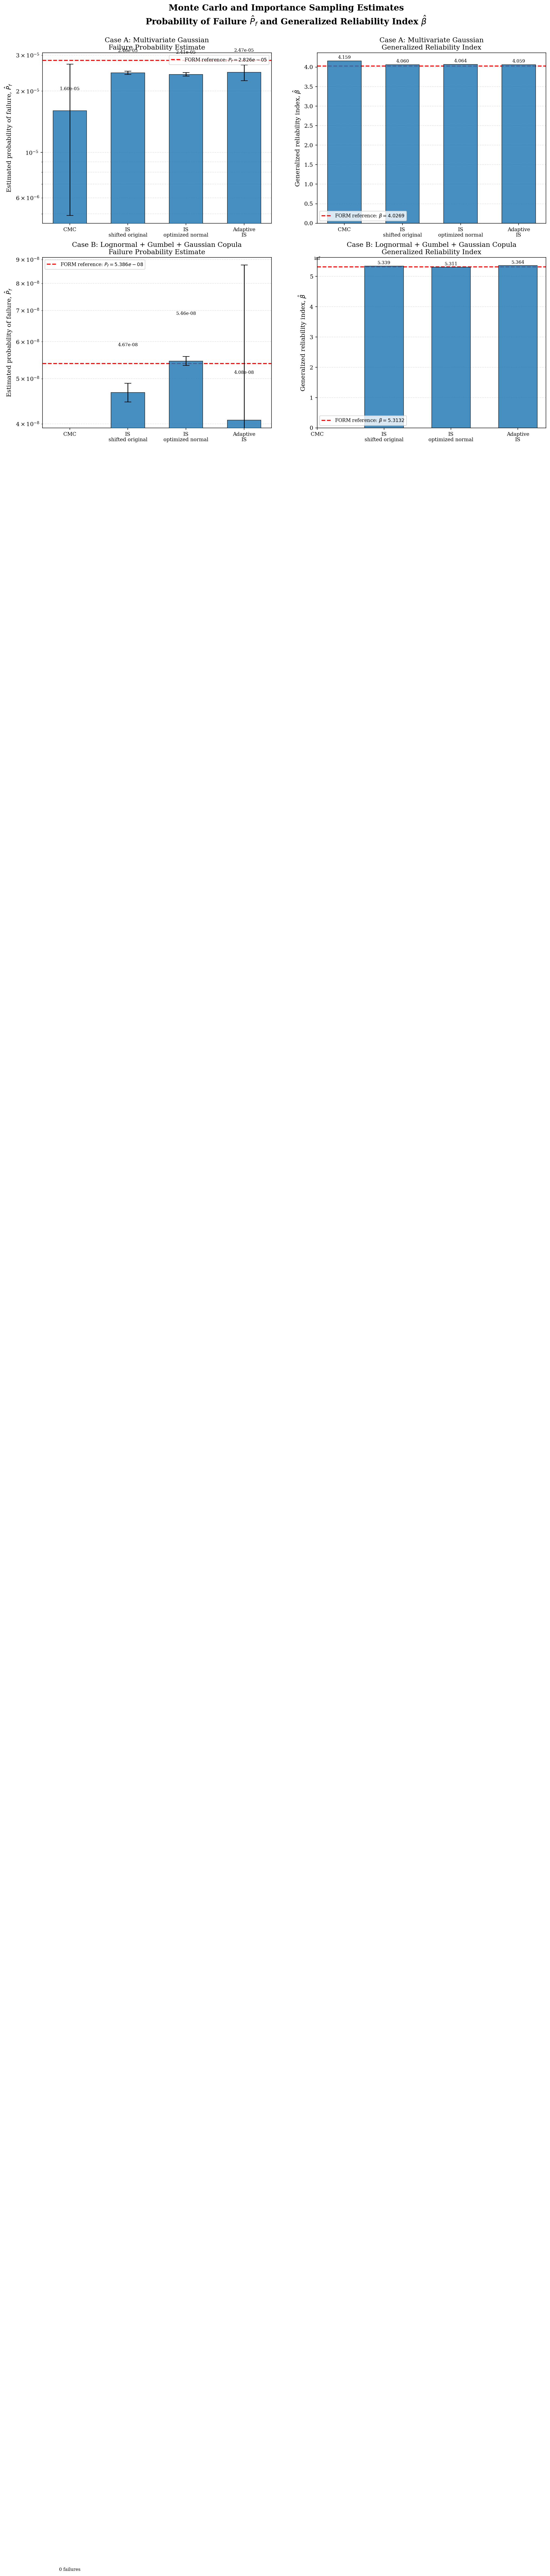


Saved:
  plot3_mc_comparison_both_cases.png
  plot3_mc_comparison_both_cases.pdf


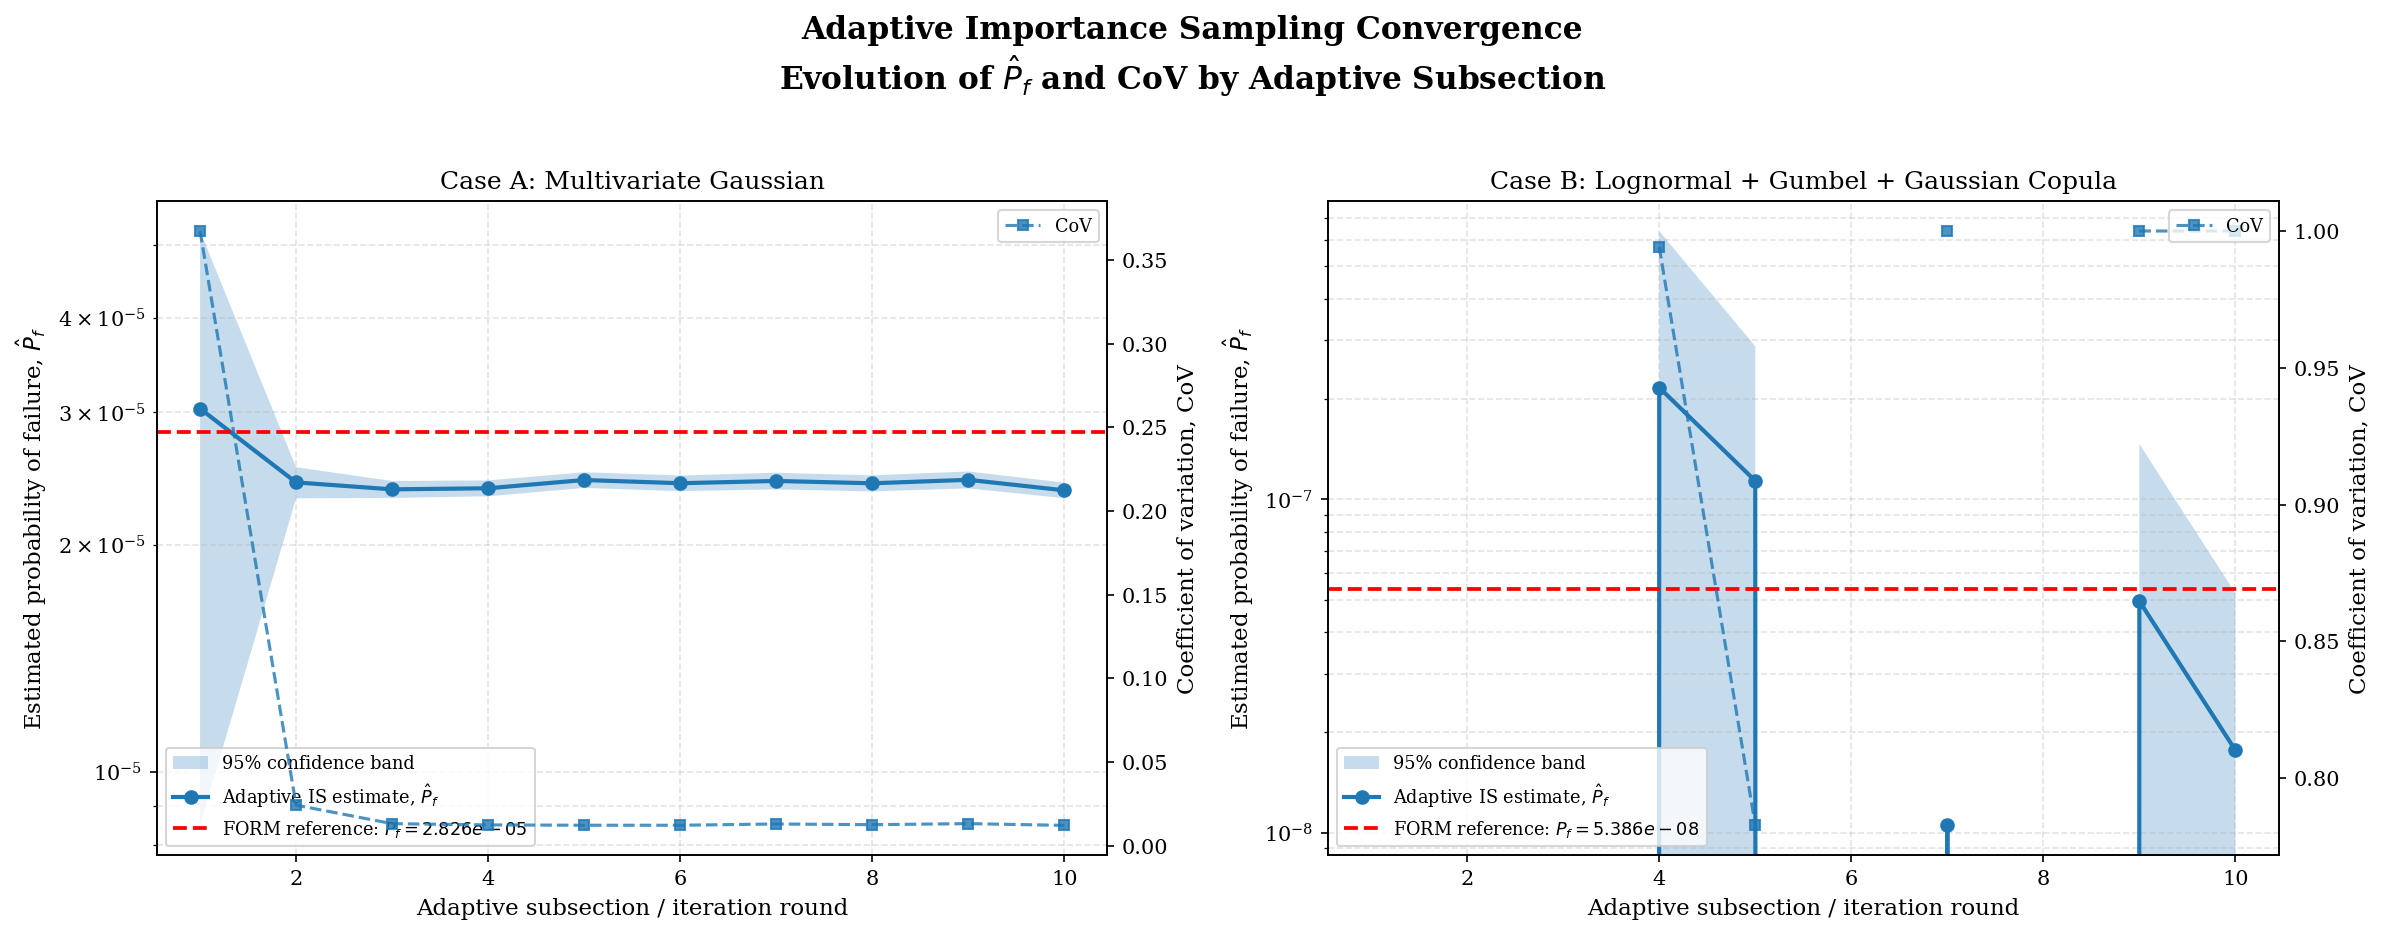


Saved:
  plot4_adaptive_IS_convergence.png
  plot4_adaptive_IS_convergence.pdf

FINAL NOTES

1. Crude Monte Carlo may give zero failures for very rare events, especially for
   the Lognormal + Gumbel + Gaussian copula case. This does not mean Pf = 0;
   it means the crude sample size is too small for such a rare event.

2. The U-space density used in the IS weights is the independent standard normal
   density because the HLRF transformation defines U as an independent standard
   normal vector.

3. The optimized-normal IS method uses a numerical pilot optimization to choose
   the covariance matrix that minimizes an estimate of the IS second moment.

4. Adaptive IS starts from the transformed mean point and updates the proposal
   mean and covariance using weighted failure samples.



In [37]:
# COMPARISON PLOTS

method_labels = [
    "CMC",
    "IS\nshifted original",
    "IS\noptimized normal",
    "Adaptive\nIS"
]

case_data = [
    ("Case A: Multivariate Gaussian", results_g, Pf_FORM_g, beta_g),
    ("Case B: Lognormal + Gumbel + Gaussian Copula", results_c, Pf_FORM_c, beta_c)
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    "Monte Carlo and Importance Sampling Estimates\n"
    r"Probability of Failure $\hat{P}_f$ and Generalized Reliability Index $\hat{\beta}$",
    fontsize=15,
    fontweight="bold",
    y=0.98
)

for row_idx, (case_name, results, Pf_FORM_ref, beta_FORM_ref) in enumerate(case_data):

    keys = list(results.keys())
    x = np.arange(len(keys))

    Pfs = np.array([results[k][0] for k in keys])
    ses = np.array([results[k][1] for k in keys])
    betas = np.array([results[k][3] for k in keys])

    ci_low = np.array([results[k][2][0] for k in keys])
    ci_high = np.array([results[k][2][1] for k in keys])

    err_low = np.maximum(Pfs - ci_low, 0.0)
    err_high = np.maximum(ci_high - Pfs, 0.0)

    # Probability of failure plot
    ax = axes[row_idx, 0]

    bars = ax.bar(
        x,
        Pfs,
        width=0.58,
        alpha=0.82,
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    ax.errorbar(
        x,
        Pfs,
        yerr=[err_low, err_high],
        fmt="none",
        color="black",
        capsize=6,
        linewidth=1.3,
        zorder=4
    )

    ax.axhline(
        Pf_FORM_ref,
        color="red",
        linestyle="--",
        linewidth=1.8,
        label=rf"FORM reference: $P_f={Pf_FORM_ref:.3e}$"
    )

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, fontsize=9)
    ax.set_ylabel(r"Estimated probability of failure, $\hat{P}_f$")
    ax.set_title(f"{case_name}\nFailure Probability Estimate")
    ax.grid(True, which="both", linestyle="--", alpha=0.35, axis="y")
    ax.legend(fontsize=8.5)

    for bar, val in zip(bars, Pfs):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val * 1.25,
                f"{val:.2e}",
                ha="center",
                va="bottom",
                fontsize=8
            )
        else:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                1e-12,
                "0 failures",
                ha="center",
                va="bottom",
                fontsize=8
            )

    # Reliability index plot
    ax2 = axes[row_idx, 1]

    beta_plot = np.array([
        b if np.isfinite(b) else np.nan
        for b in betas
    ])

    ax2.bar(
        x,
        beta_plot,
        width=0.58,
        alpha=0.82,
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    ax2.axhline(
        beta_FORM_ref,
        color="red",
        linestyle="--",
        linewidth=1.8,
        label=rf"FORM reference: $\beta={beta_FORM_ref:.4f}$"
    )

    ax2.set_xticks(x)
    ax2.set_xticklabels(method_labels, fontsize=9)
    ax2.set_ylabel(r"Generalized reliability index, $\hat{\beta}$")
    ax2.set_title(f"{case_name}\nGeneralized Reliability Index")
    ax2.grid(True, linestyle="--", alpha=0.35, axis="y")
    ax2.legend(fontsize=8.5)

    for i, val in enumerate(beta_plot):
        if np.isfinite(val):
            ax2.text(
                i,
                val + 0.03,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )
        else:
            ax2.text(
                i,
                beta_FORM_ref + 0.2,
                "inf",
                ha="center",
                va="bottom",
                fontsize=8
            )

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "plot3_mc_comparison_both_cases.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "plot3_mc_comparison_both_cases.pdf",
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print("  plot3_mc_comparison_both_cases.png")
print("  plot3_mc_comparison_both_cases.pdf")



# ADAPTIVE IMPORTANCE SAMPLING CONVERGENCE PLOTS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    "Adaptive Importance Sampling Convergence\n"
    r"Evolution of $\hat{P}_f$ and CoV by Adaptive Subsection",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

adaptive_plot_data = [
    (
        axes[0],
        ais_rounds_g,
        Pf_FORM_g,
        "Case A: Multivariate Gaussian"
    ),
    (
        axes[1],
        ais_rounds_c,
        Pf_FORM_c,
        "Case B: Lognormal + Gumbel + Gaussian Copula"
    )
]

for ax, rounds_data, Pf_FORM_ref, title in adaptive_plot_data:

    rounds = np.arange(1, len(rounds_data) + 1)

    Pf_round = np.array([r[0] for r in rounds_data])
    se_round = np.array([r[1] for r in rounds_data])
    cov_round = np.array([r[4] for r in rounds_data])

    lower = np.maximum(Pf_round - 1.96 * se_round, 0.0)
    upper = Pf_round + 1.96 * se_round

    ax.fill_between(
        rounds,
        lower,
        upper,
        alpha=0.25,
        label="95% confidence band"
    )

    ax.plot(
        rounds,
        Pf_round,
        "o-",
        linewidth=2,
        markersize=6,
        label=r"Adaptive IS estimate, $\hat{P}_f$"
    )

    ax.axhline(
        Pf_FORM_ref,
        color="red",
        linestyle="--",
        linewidth=1.8,
        label=rf"FORM reference: $P_f={Pf_FORM_ref:.3e}$"
    )

    ax.set_yscale("log")
    ax.set_xlabel("Adaptive subsection / iteration round")
    ax.set_ylabel(r"Estimated probability of failure, $\hat{P}_f$")
    ax.set_title(title)
    ax.grid(True, which="both", linestyle="--", alpha=0.35)
    ax.legend(loc="lower left", fontsize=8.5)

    ax_cov = ax.twinx()

    cov_plot = np.array([
        c if np.isfinite(c) else np.nan
        for c in cov_round
    ])

    ax_cov.plot(
        rounds,
        cov_plot,
        "s--",
        linewidth=1.5,
        markersize=5,
        alpha=0.8,
        label="CoV"
    )

    ax_cov.set_ylabel("Coefficient of variation, CoV")
    ax_cov.legend(loc="upper right", fontsize=8.5)

plt.tight_layout()

plt.savefig(
    "plot4_adaptive_IS_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "plot4_adaptive_IS_convergence.pdf",
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print("  plot4_adaptive_IS_convergence.png")
print("  plot4_adaptive_IS_convergence.pdf")


# FINAL INTERPRETIVE NOTES


print("\n" + "=" * 80)
print("FINAL NOTES")
print("=" * 80)

print("""
1. Crude Monte Carlo may give zero failures for very rare events, especially for
   the Lognormal + Gumbel + Gaussian copula case. This does not mean Pf = 0;
   it means the crude sample size is too small for such a rare event.

2. The U-space density used in the IS weights is the independent standard normal
   density because the HLRF transformation defines U as an independent standard
   normal vector.

3. The optimized-normal IS method uses a numerical pilot optimization to choose
   the covariance matrix that minimizes an estimate of the IS second moment.

4. Adaptive IS starts from the transformed mean point and updates the proposal
   mean and covariance using weighted failure samples.
""")